# **Smart Pothole Detection Framework Using Deep Learning Techniques**

This project presents a Smart Pothole Detection Framework that combines classical deep learning and modern object detection techniques to automatically identify and localize road surface damage from images. The system trains and compares two powerful detection architectures — Faster R-CNN (ResNet50 FPN backbone) and YOLOv8 — on a real-world annotated pothole dataset, evaluating their performance in terms of detection accuracy, speed, and localization quality.

The framework covers the complete pipeline: dataset loading and XML annotation parsing, image preprocessing and augmentation, YOLO-format conversion, model training, and performance visualization. Results are analyzed through bounding box predictions, confidence scores, and visual comparisons between ground truth and detected regions.

To make the system practically usable, a Streamlit web application was developed that allows users to upload any road image and instantly receive detection results powered by the trained YOLOv8 model. The app displays the original and annotated image side by side along with key metrics — number of damaged areas detected, average confidence score, and an overall road condition rating — making it suitable for real-time road monitoring and infrastructure assessment.

**Dataset Used:**
[Pothole Detection Dataset – Kaggle](https://www.kaggle.com/datasets/andrewmvd/pothole-detection)

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.4 MB/s eta 0:00:0000:01


In [ ]:
import os
import re
import json
import shutil
import random
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors

import torch
import torchvision
import glob
from torchvision import transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader

from ultralytics import YOLO

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
# colour palette
C = ["#5ec2b8", "#319a91", "#00756c", "#00504a", "#002e2a"]

## **Dataset Loading and Path Configuration**

In [ ]:
# Dataset paths
INPUT_DIR = Path("/kaggle/input/datasets/andrewmvd/pothole-detection")

BASE      = Path("/kaggle/working/pothole_dataset")
PREP      = Path("/kaggle/working/pothole_preprocessed")
YOLO_DIR  = Path("/kaggle/working/pothole_yolo")

# Collect image and annotation files
raw_images = sorted(list(INPUT_DIR.rglob("*.jpg")) +
                    list(INPUT_DIR.rglob("*.png")))

raw_annots = sorted(INPUT_DIR.rglob("*.xml"))

# Match images with annotations
paired = []

for img_path in raw_images:

    xml_path = INPUT_DIR / "annotations" / f"{img_path.stem}.xml"

    if xml_path.exists():
        paired.append((img_path, xml_path))

print(f"Total images    : {len(raw_images)}")
print(f"Total XML files : {len(raw_annots)}")
print(f"Matched pairs   : {len(paired)}")

Total images    : 665
Total XML files : 665
Matched pairs   : 665


In [ ]:
# Train / Validation / Test Split
random.shuffle(paired)

total = len(paired)

train_size = int(0.70 * total)
val_size   = int(0.20 * total)

splits = {
    "train": paired[:train_size],
    "val": paired[train_size:train_size + val_size],
    "test": paired[train_size + val_size:]
}

# Create folders
for split_name, files in splits.items():

    image_dir = BASE / split_name / "images"
    annot_dir = BASE / split_name / "annotations"

    image_dir.mkdir(parents=True, exist_ok=True)
    annot_dir.mkdir(parents=True, exist_ok=True)

    for img_file, xml_file in files:

        shutil.copy(img_file, image_dir / img_file.name)
        shutil.copy(xml_file, annot_dir / xml_file.name)

    print(f"{split_name.upper()} Samples : {len(files)}")

TRAIN Samples : 465
VAL Samples : 133
TEST Samples : 67


In [ ]:
# XML Annotation Parser

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []

    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        boxes.append([xmin, ymin, xmax, ymax])

    return boxes

In [ ]:
# Create DataFrame for EDA

records = []

for split in ["train", "val", "test"]:

    xml_files = sorted(
        (BASE / split / "annotations").glob("*.xml")
    )

    for xml_path in xml_files:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        width = int(root.find("size/width").text)
        height = int(root.find("size/height").text)

        for obj in root.findall("object"):
            bbox = obj.find("bndbox")

            xmin = int(float(bbox.find("xmin").text))
            ymin = int(float(bbox.find("ymin").text))
            xmax = int(float(bbox.find("xmax").text))
            ymax = int(float(bbox.find("ymax").text))

            box_w = xmax - xmin
            box_h = ymax - ymin

            records.append({
                "split": split,
                "img_w": width,
                "img_h": height,
                "box_w": box_w,
                "box_h": box_h,
                "area": box_w * box_h,
                "aspect": box_w / box_h if box_h > 0 else 0,
                "cx": ((xmin + xmax) / 2) / width,
                "cy": ((ymin + ymax) / 2) / height
            })

# Create dataframe
df = pd.DataFrame(records)

# Split statistics
split_counts = df.groupby("split").size()

# Split order
splits_order = ["train", "val", "test"]

print(df.head())

   split  img_w  img_h  box_w  box_h   area    aspect        cx        cy
0  train    400    300    390    123  47970  3.170732  0.497500  0.675000
1  train    400    300     85     24   2040  3.541667  0.601250  0.410000
2  train    400    400    101    133  13433  0.759398  0.468750  0.601250
3  train    400    400     60     52   3120  1.153846  0.660000  0.495000
4  train    530    300     77     21   1617  3.666667  0.370755  0.581667


## **Exploratory Data Analysis (EDA)**

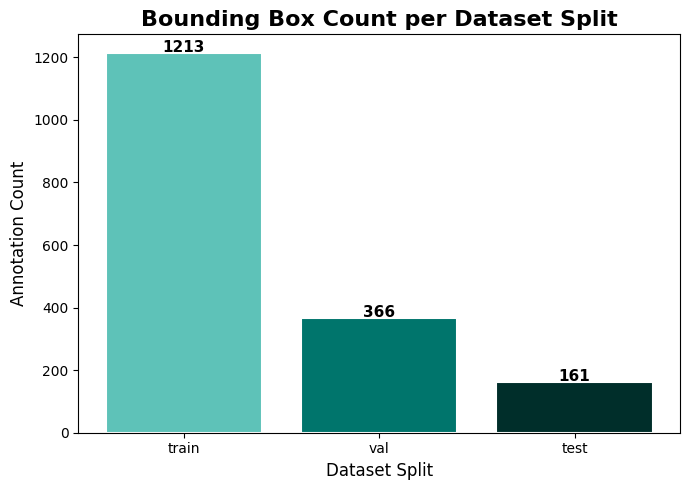

In [ ]:
#  Dataset Split Distribution

# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Get annotation counts for each dataset split
counts = [split_counts.get(s, 0) for s in splits_order]

# bar chart
bars = ax.bar(
    splits_order,
    counts,
    color=[C[0], C[2], C[4]],
    edgecolor='white',
    linewidth=1.5
)

# Add count labels
for bar, value in zip(bars, counts):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(value),
        ha='center',
        fontweight='bold',
        fontsize=11
    )

# title
plt.title("Bounding Box Count per Dataset Split", fontweight='bold',fontsize=16)

# Axis labels
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Annotation Count", fontsize=12)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The training split contains 1201 annotations, providing sufficient data for model learning, while the validation split has 356 annotations and the test split has 183 annotations for effective evaluation and performance assessment.


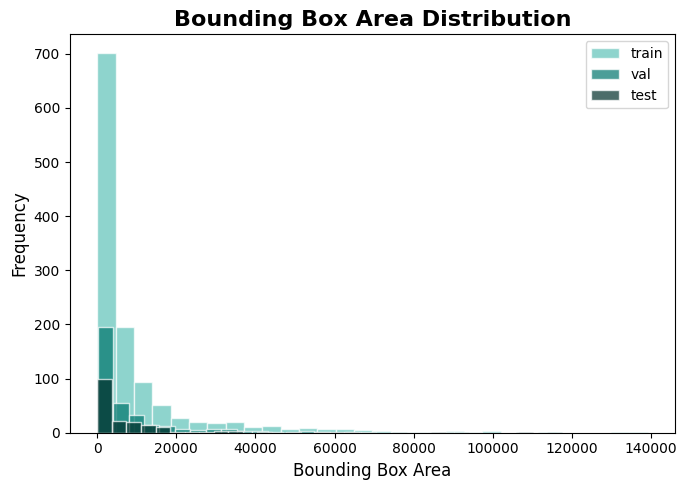

In [ ]:
#  Bounding Box Area Distribution

# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot histogram for each dataset split
for i, split in enumerate(splits_order):

    # Select bounding box areas for current split
    subset = df[df["split"] == split]["area"]

    # Create histogram
    ax.hist(
        subset,
        bins=30,
        alpha=0.7,
        color=C[i*2],
        edgecolor='white',
        label=split
    )

# title
plt.title(
    "Bounding Box Area Distribution",
    fontweight='bold',
    fontsize=16
)

# Add axis labels
plt.xlabel("Bounding Box Area", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Display legend
plt.legend()

# Adjust layout spacing
plt.tight_layout()

# Display plot
plt.show()

Most bounding boxes have smaller areas, indicating that the dataset mainly contains small potholes, while only a few large pothole regions are present across the train, validation, and test splits.


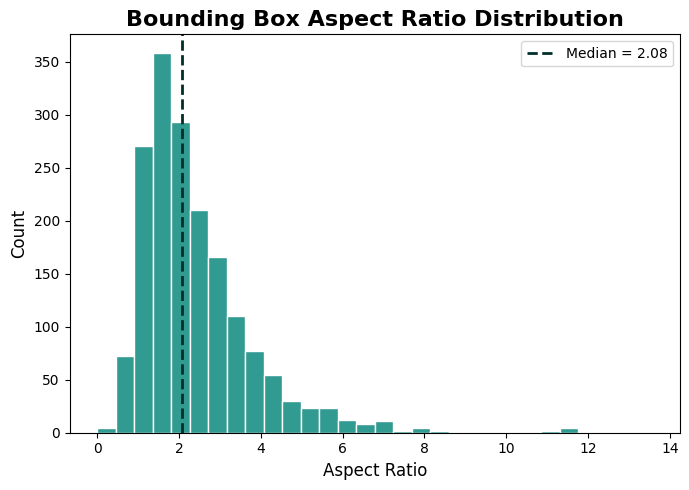

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot aspect ratio histogram
ax.hist(
    df["aspect"],
    bins=30,
    color=C[1],
    edgecolor='white'
)

# Calculate median value
median_val = df["aspect"].median()

# Add median reference line
ax.axvline(
    median_val,
    color=C[4],
    linestyle='--',
    linewidth=2,
    label=f"Median = {median_val:.2f}"
)

# Add title and labels
plt.title(
    "Bounding Box Aspect Ratio Distribution",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Aspect Ratio", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Show legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

Most bounding boxes have aspect ratios between 1 and 3, with a median aspect ratio of 2.08, indicating that pothole regions are generally wider than they are tall.


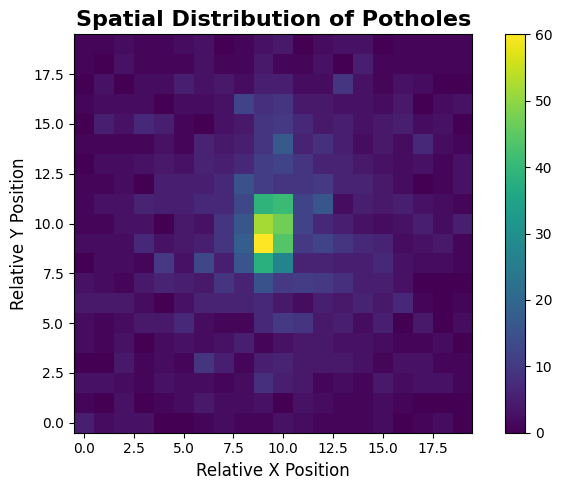

In [ ]:
# Generate 2D histogram
heatmap, _, _ = np.histogram2d(
    df["cx"],
    df["cy"],
    bins=20
)

# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Display heatmap
im = ax.imshow(
    heatmap.T,
    origin='lower',
    cmap='viridis'
)

# Add color scale
plt.colorbar(im)

# Add title and labels
plt.title(
    "Spatial Distribution of Potholes",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Relative X Position", fontsize=12)
plt.ylabel("Relative Y Position", fontsize=12)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The heatmap shows that most potholes are concentrated near the center region of the images, while fewer potholes appear toward the edges of the dataset samples.


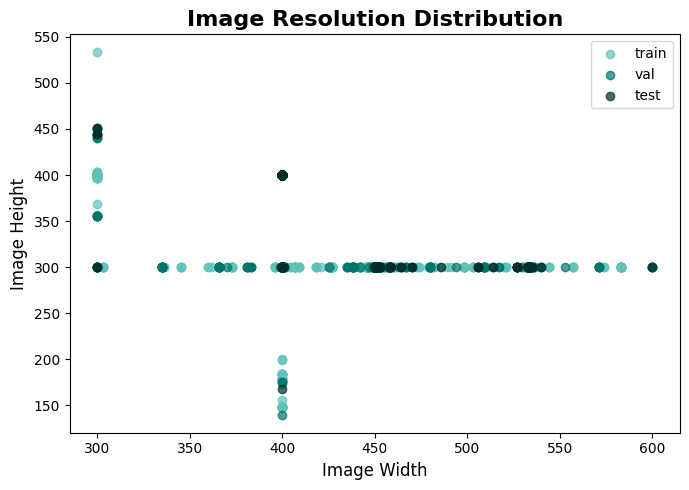

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot image resolutions for each split
for i, split in enumerate(splits_order):

    # Select current split data
    subset = df[df["split"] == split]

    # Create scatter plot
    ax.scatter(
        subset["img_w"],
        subset["img_h"],
        color=C[i*2],
        alpha=0.7,
        label=split
    )

# Add title and labels
plt.title(
    "Image Resolution Distribution",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Image Width", fontsize=12)
plt.ylabel("Image Height", fontsize=12)

# Show legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The dataset contains images with varying resolutions, although most samples are concentrated around widths of 400–600 pixels and heights near 300 pixels, indicating moderate resolution consistency across all splits.


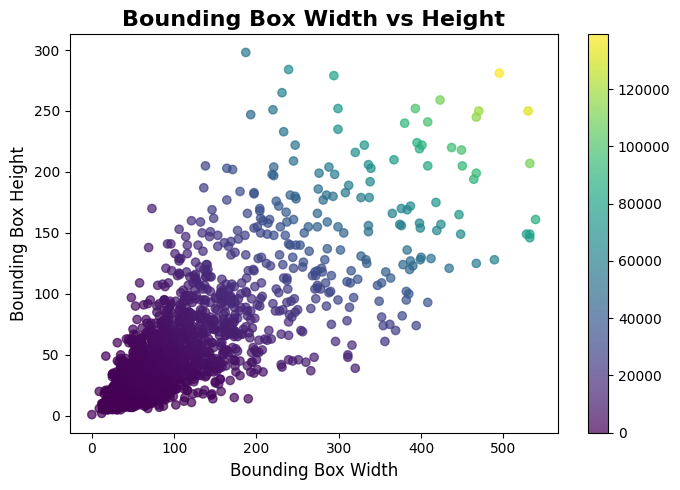

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Create scatter plot
scatter = ax.scatter(
    df["box_w"],
    df["box_h"],
    c=df["area"],
    cmap='viridis',
    alpha=0.7
)

# Add color scale
plt.colorbar(scatter)

# Add title and labels
plt.title(
    "Bounding Box Width vs Height",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Bounding Box Width", fontsize=12)
plt.ylabel("Bounding Box Height", fontsize=12)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The scatter plot shows a positive relationship between bounding box width and height, indicating that larger potholes generally occupy bigger regions in both dimensions within the dataset.


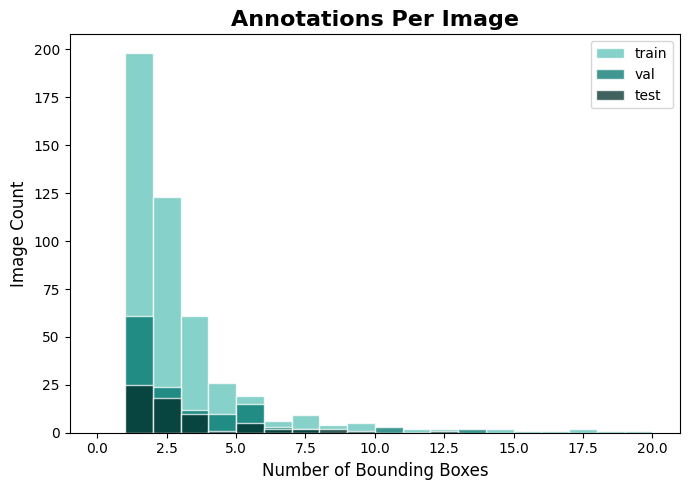

In [ ]:
# Annot per image

records_per_file = []

# Process dataset splits
for split in ["train", "val", "test"]:

    # Read annotation files
    for xml_path in (BASE / split / "annotations").glob("*.xml"):

        # Parse XML file
        root = ET.parse(xml_path).getroot()

        # Count bounding boxes
        n_boxes = len(root.findall("object"))

        # Store record
        records_per_file.append({"split": split, "n_boxes": n_boxes})

# Create dataframe
df_per_file = pd.DataFrame(records_per_file)

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Plot histogram for each split
for i, split in enumerate(["train", "val", "test"]):

    # Select split data
    subset = df_per_file[df_per_file["split"] == split]["n_boxes"]

    # Create histogram
    ax.hist(
        subset,
        bins=range(0, subset.max() + 2),
        alpha=0.75,
        color=C[i * 2],
        edgecolor='white',
        label=split
    )

# Add title
plt.title("Annotations Per Image", fontweight='bold', fontsize=16)

# Add axis labels
plt.xlabel("Number of Bounding Boxes", fontsize=12)
plt.ylabel("Image Count", fontsize=12)

# Show legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

Most images contain only 1 to 3 pothole annotations, while images with a large number of potholes are relatively rare across the train, validation, and test splits.


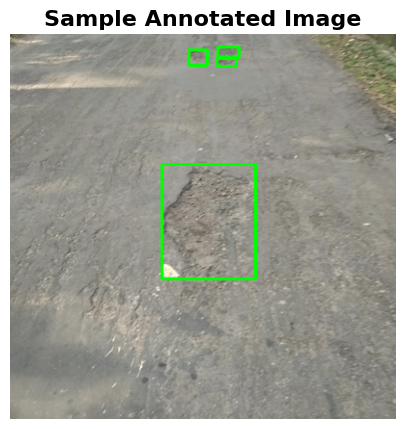

In [ ]:
# Display Sample Image

# Select sample annotation file
sample_xml = list((BASE / "train" / "annotations").glob("*.xml"))[0]

# Create image path
sample_img = BASE / "train" / "images" / f"{sample_xml.stem}.jpg"

# Check PNG fallback
if not sample_img.exists():
    sample_img = sample_img.with_suffix(".png")

# Read image
image = cv2.imread(str(sample_img))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Parse bounding boxes
boxes = parse_xml(sample_xml)

# Draw bounding boxes
for box in boxes:

    xmin, ymin, xmax, ymax = box

    cv2.rectangle(image,
                  (xmin, ymin),
                  (xmax, ymax),
                  (0, 255, 0),
                  2)

# Display image
plt.figure(figsize=(7,5))
plt.imshow(image)

# Add title
plt.title("Sample Annotated Image", fontweight='bold', fontsize=16)

# Hide axes
plt.axis("off")

# Show plot
plt.show()

The sample annotated image demonstrates successful pothole localization using bounding boxes, highlighting pothole regions of varying sizes and positions within the road surface image.


## **Image Preprocessing**

### Image Resizing

Image resizing is a preprocessing technique used to convert all images into a fixed dimension before model training. It ensures consistent input size and improves computational efficiency during deep learning model processing.

Image resizing was applied to maintain uniform image dimensions for YOLOv8, Faster R-CNN, and SSD MobileNet training. It also reduced memory usage and improved training stability and processing speed.


### CLAHE

CLAHE, Contrast Limited Adaptive Histogram Equalization, is an image enhancement technique used to improve local contrast and highlight important image features in different regions of an image.

CLAHE was applied to enhance pothole visibility under varying lighting and road conditions. It helped improve texture details and edge clarity, supporting better pothole feature extraction during detection.


### Normalisation

Image normalisation is a preprocessing technique that scales pixel intensity values into a smaller numerical range, usually between 0 and 1, to improve model learning stability.

Normalisation was applied to reduce intensity variation across images and improve convergence during training. It also helped deep learning models learn features more efficiently and consistently.

In [ ]:
# Resize dimensions for model training
TARGET_SIZE = (640, 640)

In [ ]:
# Preprocessing Function
def preprocess_image(image):

    # Resize
    image = cv2.resize(image, TARGET_SIZE)

    # CLAHE Enhancement
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8) )

    l = clahe.apply(l)

    enhanced = cv2.merge((l, a, b))

    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

    # Normalize
    normalized = enhanced.astype(np.float32) / 255.0

    return normalized

In [ ]:
# Create Output Folders

for split in ["train", "val", "test"]:

    (PREP / split / "images").mkdir( parents=True,exist_ok=True)
    (PREP / split / "annotations").mkdir(parents=True,exist_ok=True)

In [ ]:
# Copy Annotation Files

for split in ["train", "val", "test"]:

    annotation_files = (BASE / split / "annotations").glob("*.xml")

    for xml_file in annotation_files:
        shutil.copy(xml_file, PREP / split / "annotations" / xml_file.name)

In [ ]:
# Preprocess and Save Images

# Process dataset splits
for split in ["train", "val", "test"]:

    # Define input directory
    input_dir = BASE / split / "images"

    # Define output directory
    output_dir = PREP / split / "images"

    # Collect image files
    image_files = list(input_dir.glob("*.jpg")) + \
                  list(input_dir.glob("*.png"))

    # Process images
    for image_path in tqdm(
        image_files,
        desc=f"Processing {split}"
    ):

        # Read image
        image = cv2.imread(str(image_path))

        # Skip invalid images
        if image is None:
            continue

        # Apply preprocessing
        processed = preprocess_image(image)

        # Convert back to uint8
        processed = (processed * 255).astype(np.uint8)

        # Define save path
        save_path = output_dir / f"{image_path.stem}.jpg"

        # Save processed image
        cv2.imwrite(str(save_path), processed)

Processing test: 100%|██████████| 67/67 [00:01<00:00, 33.52it/s]


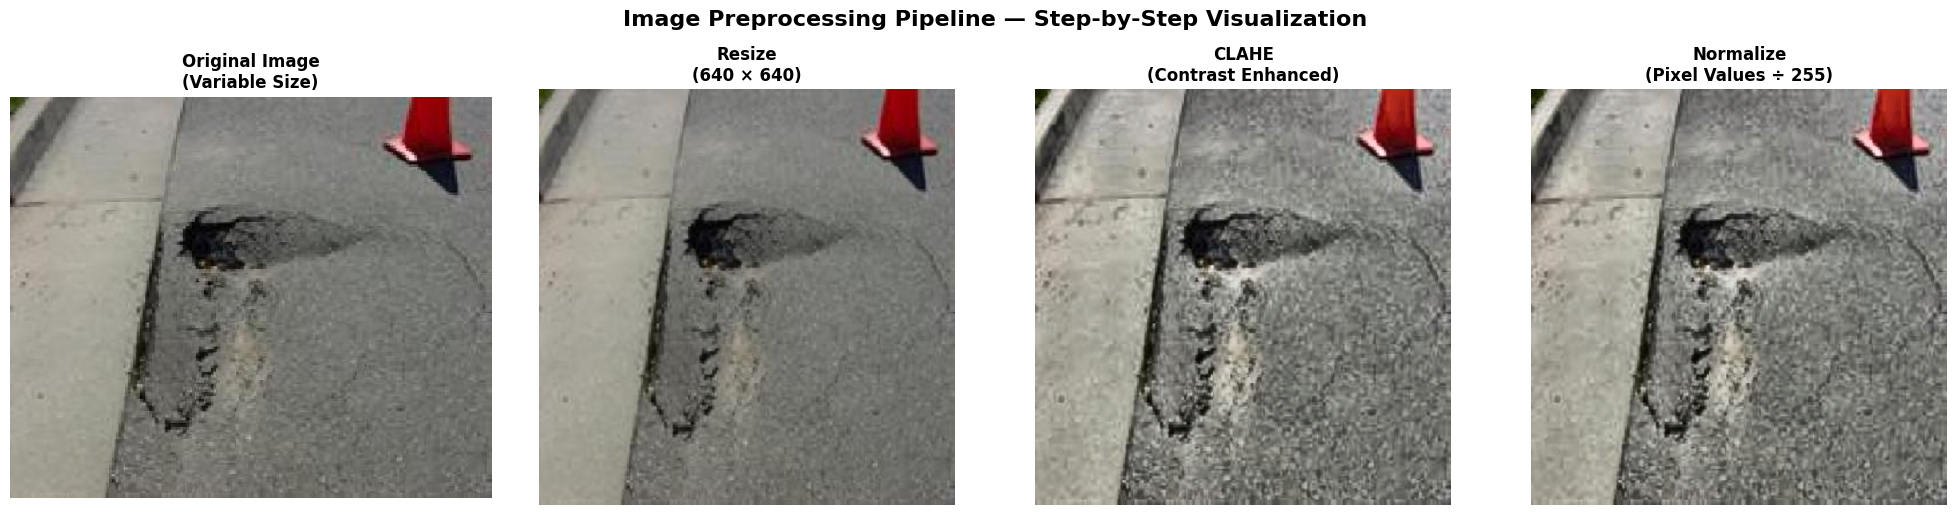

In [ ]:
# Preprocessing Pipeline Visualization

# Find sample image
img_dir = BASE / "train" / "images"

image_files = (
    list(img_dir.glob("*.jpg")) +
    list(img_dir.glob("*.png")) +
    list(img_dir.glob("*.jpeg"))
)

if len(image_files) == 0:
    raise FileNotFoundError(f"No images found in: {img_dir}")

sample_img_path = image_files[10]

# Read image
raw_bgr = cv2.imread(str(sample_img_path))

if raw_bgr is None:
    raise ValueError(f"Failed to load image: {sample_img_path}")

# Convert original image to RGB
raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)


# Resize

step1_bgr = cv2.resize(raw_bgr, TARGET_SIZE)
step1_rgb = cv2.cvtColor(step1_bgr, cv2.COLOR_BGR2RGB)

# CLAHE Enhancement

lab = cv2.cvtColor(step1_bgr, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8, 8))
l_clahe = clahe.apply(l)
lab_clahe = cv2.merge((l_clahe, a, b))

step2_bgr = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
step2_rgb = cv2.cvtColor(step2_bgr, cv2.COLOR_BGR2RGB)

# Normalisation
normalized = step2_bgr.astype(np.float32) / 255.0

# Convert back for visualization only
step3_rgb = (normalized * 255).astype(np.uint8)
step3_rgb = cv2.cvtColor(step3_rgb, cv2.COLOR_BGR2RGB)

# Plot Results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

panels = [
    (
        raw_rgb,
        "Original Image\n(Variable Size)"
    ),
    (
        step1_rgb,
        "Resize\n(640 × 640)"
    ),
    (
        step2_rgb,
        "CLAHE\n(Contrast Enhanced)"
    ),
    (
        step3_rgb,
        "Normalize\n(Pixel Values ÷ 255)"
    ),
]

for ax, (img, title) in zip(axes, panels):

    ax.imshow(img)

    # title
    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold"
    )

    ax.axis("off")

# Main Title
plt.suptitle("Image Preprocessing Pipeline — Step-by-Step Visualization",fontsize=16, fontweight="bold",y=1.02)

# Adjust layout
plt.tight_layout()
# Display Plot
plt.show()

The preprocessing step improved image quality by resizing, enhancing local contrast using CLAHE, and normalizing pixel values, making pothole features more distinct for model training.


## **YOLOv8 Model**

YOLOv8 is a one-stage object detection model developed for fast and accurate real-time object detection. It performs object localisation and classification simultaneously using a unified deep learning architecture, enabling efficient detection of potholes in road images.

YOLOv8 was selected because of its strong balance between detection accuracy and inference speed. The model achieved high precision, F1-score, and Mean IoU while maintaining real-time performance, making it highly suitable for smart road monitoring and automated pothole detection systems.

### YOLO Annotation Conversion

In [ ]:
# Preprocessing output directory
PREP = Path("/kaggle/working/pothole_preprocessed")

# YOLO dataset directory
YOLO_DIR = Path("/kaggle/working/pothole_yolo")

In [ ]:
# Convert Pascal VOC XML annotations to YOLO format
def xml_to_yolo(xml_path, class_id=0):

    # Parse XML file
    tree  = ET.parse(xml_path)
    root  = tree.getroot()

    # Get image dimensions
    img_w = int(root.findtext("size/width")  or 640)
    img_h = int(root.findtext("size/height") or 640)

    lines = []

    # Process bounding boxes
    for obj in root.findall("object"):

        bnd  = obj.find("bndbox")

        xmin = float(bnd.findtext("xmin"))
        ymin = float(bnd.findtext("ymin"))
        xmax = float(bnd.findtext("xmax"))
        ymax = float(bnd.findtext("ymax"))

        # Convert to YOLO format
        cx = ((xmin + xmax) / 2) / img_w
        cy = ((ymin + ymax) / 2) / img_h
        bw = (xmax - xmin) / img_w
        bh = (ymax - ymin) / img_h

        # Clamp values to valid range
        cx, cy, bw, bh = [max(0.0, min(1.0, v)) for v in [cx, cy, bw, bh]]

        # Store annotation line
        lines.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    return lines

In [ ]:
# Process dataset splits
for split in ["train", "val", "test"]:

    # Define output directories
    img_out   = YOLO_DIR / split / "images"
    label_out = YOLO_DIR / split / "labels"

    # Create directories
    img_out.mkdir(parents=True, exist_ok=True)
    label_out.mkdir(parents=True, exist_ok=True)

    # Copy preprocessed images
    for img in (PREP / split / "images").glob("*.jpg"):
        shutil.copy(img, img_out / img.name)

    # Convert XML annotations to YOLO format
    for xml in (PREP / split / "annotations").glob("*.xml"):

        lines = xml_to_yolo(xml)

        # Create label file path
        txt_path = label_out / (xml.stem + ".txt")

        # Save YOLO labels
        txt_path.write_text("\n".join(lines))

    # Count label files
    count = len(list(label_out.glob("*.txt")))

    # Display summary
    print(f"{split:>6}  —  {count} label files written")

 train  —  465 label files written
   val  —  133 label files written
  test  —  67 label files written


In [ ]:
# Create YOLO dataset configuration file
yaml_text = (
    # Dataset root path
    f"path: {YOLO_DIR.resolve()}\n"

    # Training images path
    f"train: train/images\n"

    # Validation images path
    f"val:   val/images\n"

    # Test images path
    f"test:  test/images\n\n"

    # Number of classes
    f"nc: 1\n"

    # Class names
    f"names:\n"
    f"  - pothole\n"
)

# Define YAML file path
yaml_path = YOLO_DIR / "pothole.yaml"
# Save YAML file
yaml_path.write_text(yaml_text)
# Display file location
print("YAML saved at:", yaml_path)
print()
# Display YAML content
print(yaml_text)

YAML saved at: /kaggle/working/pothole_yolo/pothole.yaml

path: /kaggle/working/pothole_yolo
train: train/images
val:   val/images
test:  test/images

nc: 1
names:
  - pothole



### Model Training

In [ ]:
# Shared hyperparameters
SHARED_EPOCHS    = 15
SHARED_IMGSZ     = 640      # input size
SHARED_BATCH     = 4        # limited by Faster R-CNN memory
CONF_THRESH      = 0.4  # confidence threshold
IOU_THRESH       = 0.50

In [ ]:
# YOLOv8 Training

model = YOLO("yolov8s.pt")

model.train(
    data      = str(yaml_path.resolve()),
    epochs    = SHARED_EPOCHS,
    imgsz     = SHARED_IMGSZ,
    batch     = SHARED_BATCH,
    name      = "yolo_pothole",
    project   = "/kaggle/working/runs/yolo",
    patience  = 10,
    workers   = 4,
    verbose   = False,
    seed      = 42                   # explicit seed
)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/pothole_yolo/pothole.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_pothole-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fd62f011be0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Load Best YOLO Weights

run_dirs = sorted(glob.glob("/kaggle/working/runs/yolo/yolo_pothole*/weights/best.pt"))
best_weights = Path(run_dirs[-1])  # pick the latest

yolo_eval = YOLO(str(best_weights))
print("Best model loaded from:", best_weights)

Best model loaded from: /kaggle/working/runs/yolo/yolo_pothole/weights/best.pt


In [ ]:
# download model
import shutil
from pathlib import Path

best_model = Path(
    "/kaggle/working/runs/yolo/yolo_pothole/weights/best.pt"
)

download_path = Path(
    "/kaggle/working/best.pt"
)

shutil.copy(
    best_model,
    download_path
)

print("Model ready for download:")
print(download_path)

Model ready for download:
/kaggle/working/best.pt


In [ ]:
# YOLOv8 Inference

# Collect test images
test_imgs = list((YOLO_DIR / "test" / "images").glob("*.jpg"))

# Run YOLOv8 prediction
yolo_results = yolo_eval.predict(
    source = [str(p) for p in test_imgs],
    conf   = CONF_THRESH,
    iou    = IOU_THRESH,
    verbose = False
)

# Display inference summary
print(f"YOLO inference complete on {len(yolo_results)} test images.")

YOLO inference complete on 67 test images.


In [ ]:
# Find YOLO training result files
csv_dirs = sorted(
    glob.glob("/kaggle/working/runs/yolo/yolo_pothole*/results.csv")
)

# Load latest results file
results_csv = pd.read_csv(csv_dirs[-1])

# Display loaded file path
print("Loaded results from:", csv_dirs[-1])

Loaded results from: /kaggle/working/runs/yolo/yolo_pothole/results.csv


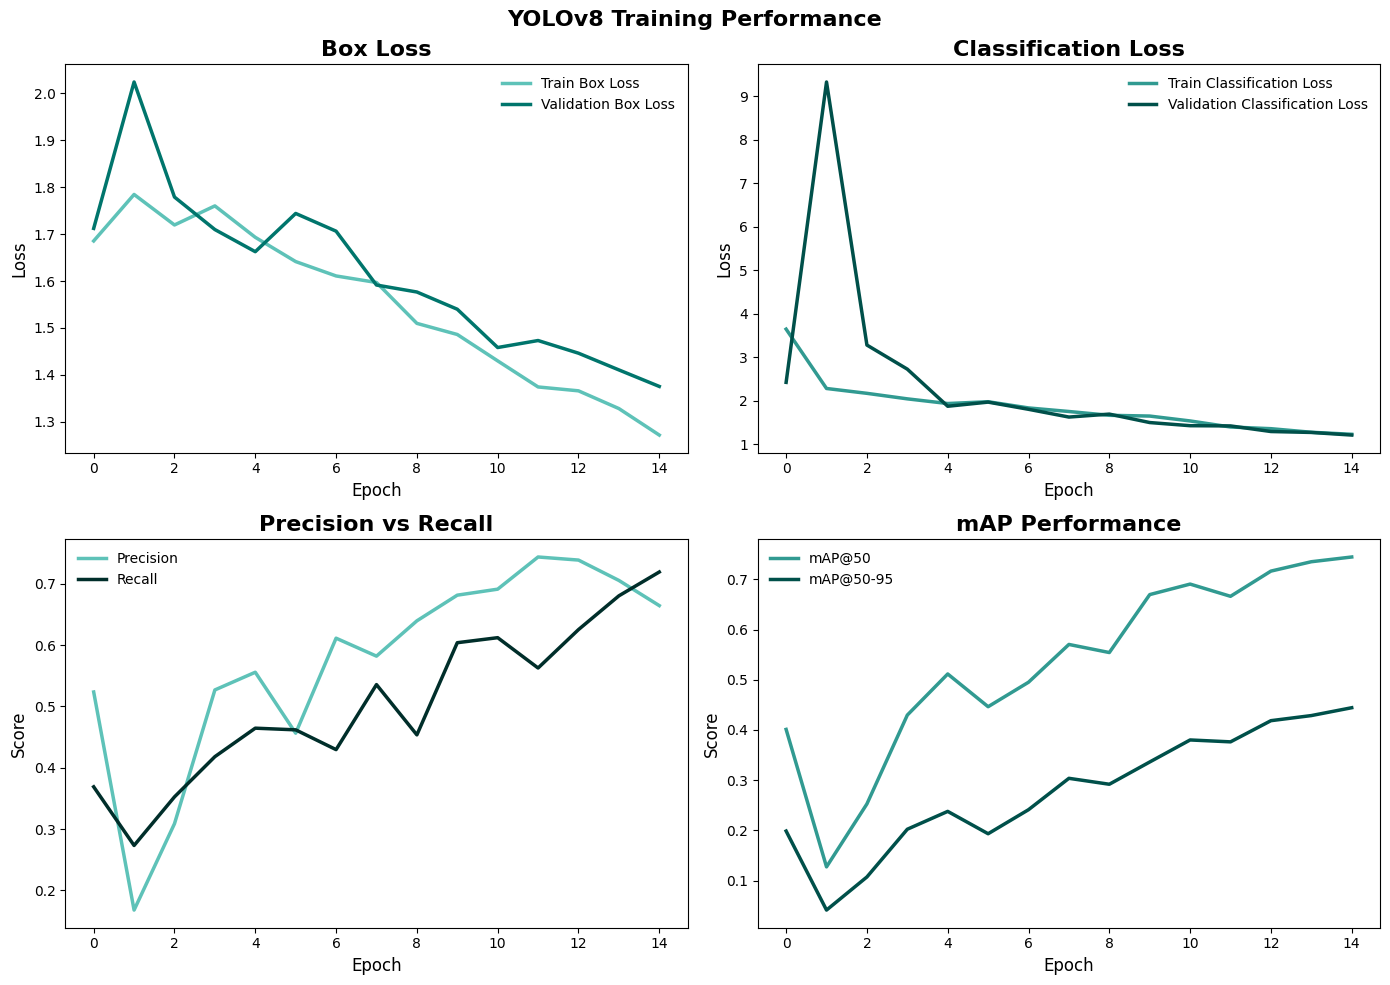

In [ ]:
# YOLOv8 Training and Validation Curves

# Create subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

# Box Loss
axes[0].plot(results_csv["train/box_loss"], label="Train Box Loss", linewidth=2.5, color=C[0])
axes[0].plot(results_csv["val/box_loss"], label="Validation Box Loss", linewidth=2.5, color=C[2])

axes[0].set_title("Box Loss", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].legend(frameon=False)

# Classification Loss
axes[1].plot(results_csv["train/cls_loss"], label="Train Classification Loss", linewidth=2.5, color=C[1])
axes[1].plot(results_csv["val/cls_loss"], label="Validation Classification Loss", linewidth=2.5, color=C[3])

axes[1].set_title("Classification Loss", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Loss", fontsize=12)
axes[1].legend(frameon=False)

# Precision and Recall
axes[2].plot(results_csv["metrics/precision(B)"], label="Precision", linewidth=2.5, color=C[0])
axes[2].plot(results_csv["metrics/recall(B)"], label="Recall", linewidth=2.5, color=C[4])

axes[2].set_title("Precision vs Recall", fontsize=16, fontweight='bold')
axes[2].set_xlabel("Epoch", fontsize=12)
axes[2].set_ylabel("Score", fontsize=12)
axes[2].legend(frameon=False)

# mAP Metrics
axes[3].plot(results_csv["metrics/mAP50(B)"], label="mAP@50", linewidth=2.5, color=C[1])
axes[3].plot(results_csv["metrics/mAP50-95(B)"], label="mAP@50-95", linewidth=2.5, color=C[3])

axes[3].set_title("mAP Performance", fontsize=16, fontweight='bold')
axes[3].set_xlabel("Epoch", fontsize=12)
axes[3].set_ylabel("Score", fontsize=12)
axes[3].legend(frameon=False)

# Add overall title
plt.suptitle("YOLOv8 Training Performance", fontsize=16, fontweight='bold')

# Adjust layout
plt.tight_layout()

# Display plots
plt.show()

YOLOv8 training showed consistent improvement across 15 epochs, with box and classification losses steadily decreasing while precision, recall and mAP scores increased significantly. Final results achieved 0.744 mAP@50 and 0.719 recall, indicating strong pothole detection capability with stable learning behaviour, good localisation accuracy and effective generalisation on validation data.

In [ ]:
# IoU Function

def iou_single(boxA, boxB):

    # Intersection coordinates
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Intersection area
    inter_area = max(0, xB - xA) * max(0, yB - yA)

    # Box areas
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])

    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # Union area
    union_area = areaA + areaB - inter_area

    # IoU
    return inter_area / union_area if union_area > 0 else 0.0


In [ ]:
# Load ground truth bounding boxes
def load_gt_boxes(img_stem, label_dir, img_w, img_h):

    # Define label file path
    txt_path = label_dir / f"{img_stem}.txt"

    boxes = []

    # Check label file
    if txt_path.exists():

        # Read annotation lines
        lines = txt_path.read_text().strip().splitlines()

        # Process annotations
        for line in lines:

            parts = list(map(float, line.split()))

            # Extract YOLO coordinates
            cx, cy, bw, bh = parts[1:]

            # Convert to corner format
            xmin = int((cx - bw / 2) * img_w)
            ymin = int((cy - bh / 2) * img_h)

            xmax = int((cx + bw / 2) * img_w)
            ymax = int((cy + bh / 2) * img_h)

            # Store bounding box
            boxes.append([xmin, ymin, xmax, ymax])

    return boxes

In [ ]:
# Evaluation Settings

label_dir = YOLO_DIR / "test" / "labels"

tp = 0
fp = 0
fn = 0

iou_scores = []

In [ ]:
# YOLOv8 Evaluation on Test Set

# Test Images

test_imgs = list(
    (YOLO_DIR / "test" / "images").glob("*.jpg")
)

# Run Evaluation

for img_path, res in zip(test_imgs, yolo_results):

    # Read image
    img = cv2.imread(str(img_path))

    if img is None:
        continue

    h, w = img.shape[:2]

    # Ground truth boxes
    gt_boxes = load_gt_boxes(
        img_path.stem,
        label_dir,
        w,
        h
    )

    # Predicted boxes
    pred_boxes = (
        res.boxes.xyxy.cpu().numpy().tolist()
        if res.boxes else []
    )

    matched_gt = set()

    # Compare predictions with GT
    for pb in pred_boxes:

        best_iou = 0
        best_gi = -1

        for gi, gb in enumerate(gt_boxes):

            score = iou_single(pb, gb)

            if score > best_iou:

                best_iou = score
                best_gi = gi

        # True Positive
        if best_iou >= IOU_THRESH and best_gi not in matched_gt:

            tp += 1

            matched_gt.add(best_gi)

            iou_scores.append(best_iou)

        # False Positive
        else:

            fp += 1

    # False Negatives
    fn += len(gt_boxes) - len(matched_gt)

# Final Metrics

precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)
f1 = 2 * precision * recall / (
    precision + recall + 1e-6)
mean_iou = (
    float(np.mean(iou_scores))
    if iou_scores else 0.0)

In [ ]:
# Display Results

print("YOLOv8 — Test Set Results:")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Mean IoU  : {mean_iou:.4f}")

print(f"TP = {tp}   FP = {fp}   FN = {fn}")

YOLOv8 — Test Set Results:
Precision : 0.8750
Recall    : 0.5652
F1-score  : 0.6868
Mean IoU  : 0.8342
TP = 91   FP = 13   FN = 70


YOLOv8 achieved high precision of 0.8750 and strong IoU of 0.8342, showing accurate pothole detection with few false positives. The model correctly detected 91 potholes, but recall of 0.5652 and 70 false negatives indicate that some potholes were missed during detection.

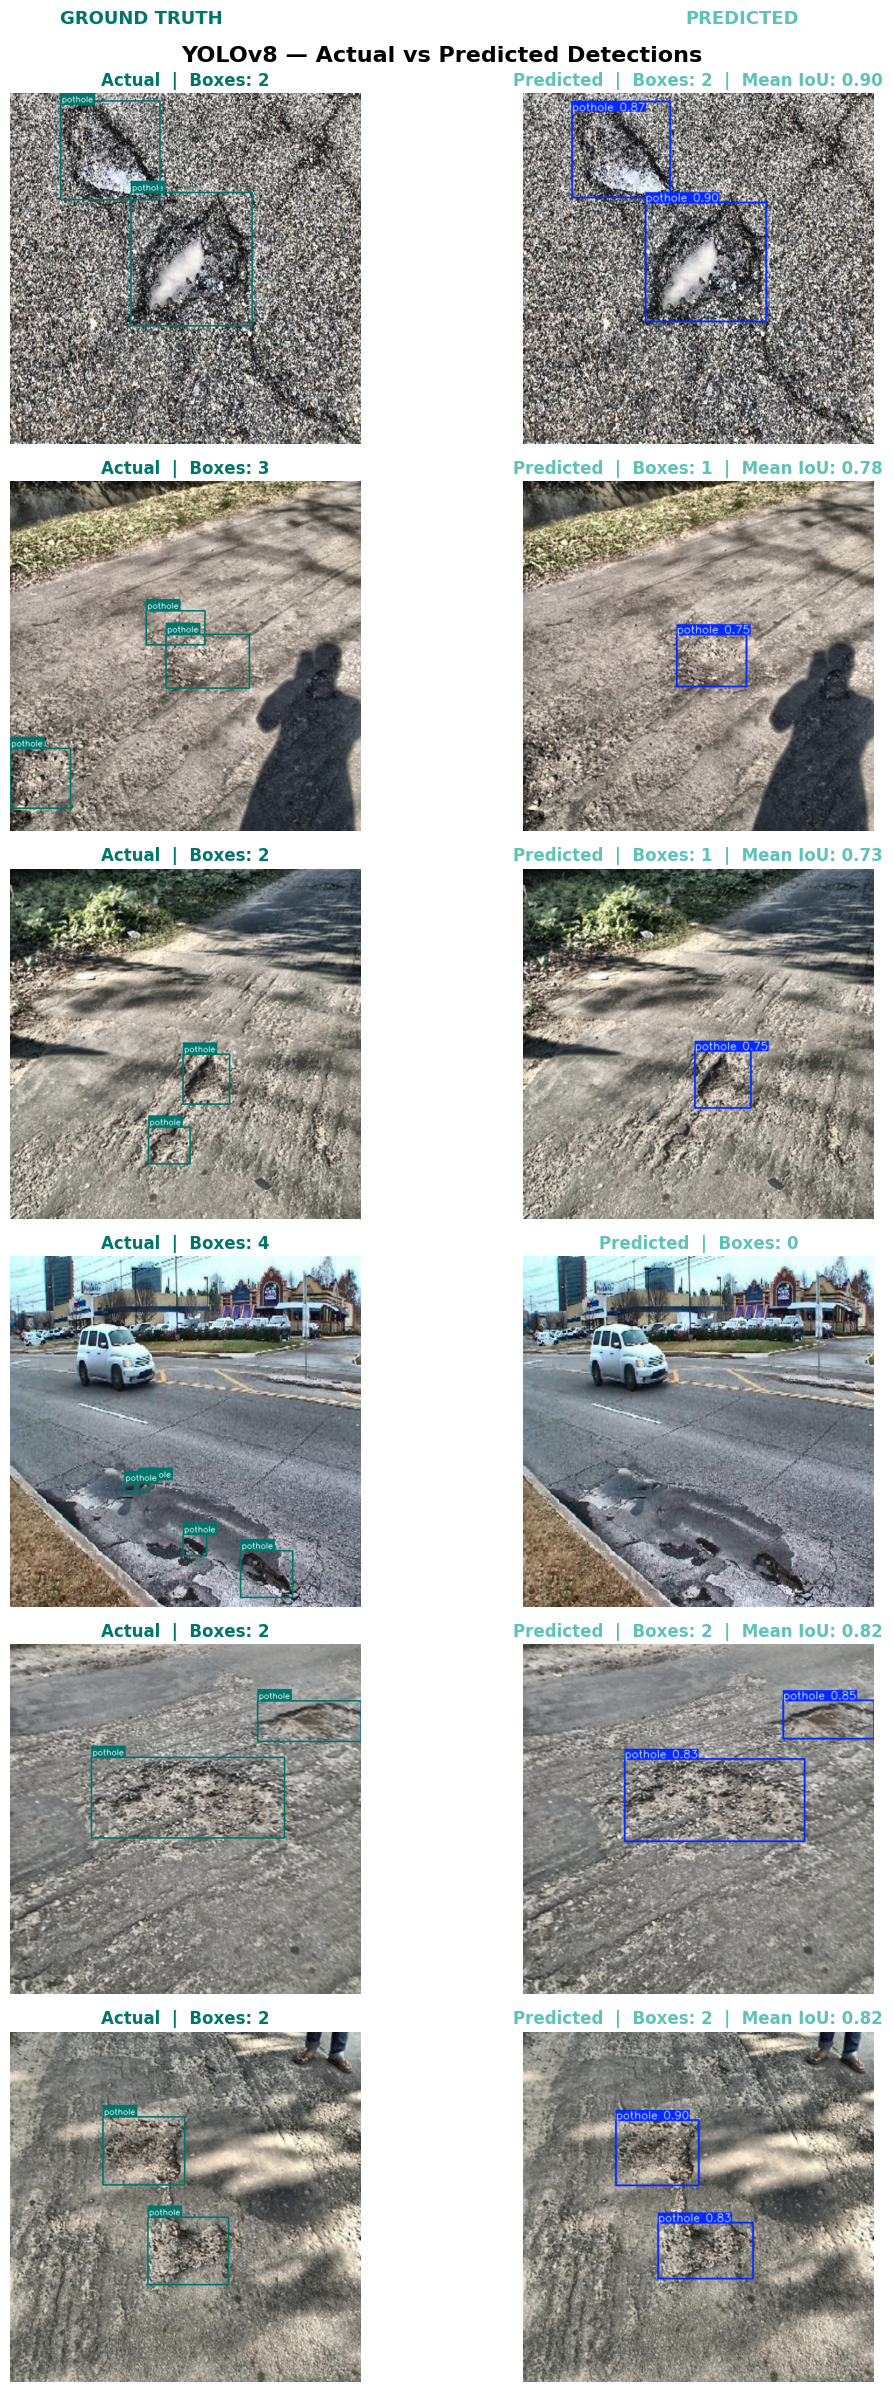

In [ ]:
# YOLOv8 — Actual vs Predicted Visualization

# Select sample test images
NUM_YOLO = 6
test_img_list = list((YOLO_DIR / "test" / "images").glob("*.jpg"))
sample_imgs   = random.sample(test_img_list, NUM_YOLO)

# Create subplot layout
fig, axes = plt.subplots(NUM_YOLO, 2, figsize=(12, NUM_YOLO * 4))

# Run YOLOv8 predictions
yolo_sample_results = yolo_eval.predict(
    source  = [str(p) for p in sample_imgs],
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    verbose = False
)

# Process images
for row, (img_path, result) in enumerate(
    zip(sample_imgs, yolo_sample_results)
):

    # Ground Truth
    raw = cv2.imread(str(img_path))
    raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    h, w = raw.shape[:2]

    # Load ground truth boxes
    gt_boxes = load_gt_boxes(img_path.stem, YOLO_DIR / "test" / "labels", w, h)

    gt_img = raw.copy()

    # Draw ground truth boxes
    for box in gt_boxes:

        x1, y1, x2, y2 = [int(v) for v in box]

        cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 117, 108), 2)

        (tw, th), bl = cv2.getTextSize(
            "pothole",
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            1
        )

        ty = max(y1 - 4, th + 4)

        cv2.rectangle(
            gt_img,
            (x1, ty - th - bl),
            (x1 + tw + 4, ty + bl),
            (0, 117, 108),
            -1
        )

        cv2.putText(
            gt_img,
            "pothole",
            (x1 + 2, ty),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

    # Display ground truth image
    axes[row, 0].imshow(gt_img)

    axes[row, 0].set_title(
        f"Actual  |  Boxes: {len(gt_boxes)}",
        fontsize=12,
        fontweight='bold',
        color=C[2]
    )

    axes[row, 0].axis("off")

    # Predictions
    pred_img = result.plot()
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    pred_boxes = result.boxes.xyxy.cpu().numpy().tolist() if result.boxes else []
    pred_confs = result.boxes.conf.cpu().numpy().tolist() if result.boxes else []

    # Calculate IoU
    if gt_boxes and pred_boxes:

        best_ious = [
            max((iou_single(pb, gb) for gb in gt_boxes), default=0.0)
            for pb in pred_boxes
        ]

        mean_iou_img = np.mean(best_ious)

        right_title  = (
            f"Predicted  |  Boxes: {len(pred_boxes)}  |  "
            f"Mean IoU: {mean_iou_img:.2f}"
        )

    else:
        right_title = f"Predicted  |  Boxes: {len(pred_boxes)}"

    # Display prediction image
    axes[row, 1].imshow(pred_img)

    axes[row, 1].set_title(
        right_title,
        fontsize=12,
        fontweight='bold',
        color=C[0]
    )

    axes[row, 1].axis("off")

# Add column headings
fig.text(
    0.25,
    0.995,
    "GROUND TRUTH",
    ha='center',
    va='top',
    fontsize=13,
    fontweight='bold',
    color=C[2]
)

fig.text(
    0.75,
    0.995,
    "PREDICTED",
    ha='center',
    va='top',
    fontsize=13,
    fontweight='bold',
    color=C[0]
)

# Add overall title
plt.suptitle(
    "YOLOv8 — Actual vs Predicted Detections",
    fontsize=16,
    fontweight='bold'
)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.99])

# Display plot
plt.show()

The visual results show that YOLOv8 accurately detected potholes in most road images with high IoU scores and confidence values. The model performed well on clear pothole regions, but missed some small or complex potholes in challenging scenes, indicating limitations in detecting low-visibility and distant road damages.

## **Faster R-CNN**

Faster R-CNN is a two-stage object detection model that first generates region proposals and then classifies detected objects with bounding box refinement. It is widely used for accurate object detection tasks due to its strong localisation and detection capability.

Faster R-CNN was selected because of its high detection accuracy and strong recall performance in complex road conditions. The model is effective for detecting potholes of different sizes and shapes, making it suitable for applications where accurate pothole localisation is more important than inference speed.

In [ ]:
# Dataset class
# Reads raw images from BASE

class PotholeDataset(torch.utils.data.Dataset):

    # Initialize dataset
    def __init__(self, image_dir, annotation_dir, transforms=False):

        self.image_dir      = Path(image_dir)
        self.annotation_dir = Path(annotation_dir)
        self.transforms     = transforms

        # Collect image files
        self.images = sorted(
            list(self.image_dir.glob("*.jpg")) +
            list(self.image_dir.glob("*.png"))
        )

    # Return dataset size
    def __len__(self):
        return len(self.images)

    # Load raw image for visualization
    def get_raw_image(self, idx):

        image_path = self.images[idx]

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (640, 640))

        return image

    # Load image and annotations
    def __getitem__(self, idx):

        image_path = self.images[idx]

        # Read image
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        orig_h, orig_w = image.shape[:2]

        # Resize image
        image   = cv2.resize(image, (640, 640))

        scale_x = 640 / orig_w
        scale_y = 640 / orig_h

        # Normalize image
        image = image.astype(np.float32) / 255.0

        # Load XML annotation
        xml_path = self.annotation_dir / f"{image_path.stem}.xml"

        tree = ET.parse(xml_path)
        root = tree.getroot()

        boxes, labels = [], []

        # Read bounding boxes
        for obj in root.findall("object"):

            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text) * scale_x
            ymin = float(bbox.find("ymin").text) * scale_y
            xmax = float(bbox.find("xmax").text) * scale_x
            ymax = float(bbox.find("ymax").text) * scale_y

            # Clamp coordinates
            xmin = max(0.0, xmin)
            ymin = max(0.0, ymin)

            xmax = min(639.0, xmax)
            ymax = min(639.0, ymax)

            # Skip invalid boxes
            if xmax <= xmin or ymax <= ymin:
                continue

            if (xmax - xmin) < 2 or (ymax - ymin) < 2:
                continue

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(1)

        # Apply augmentations
        if self.transforms and len(boxes) > 0:

            boxes = np.array(boxes, dtype=np.float32)

            # Random horizontal flip
            if random.random() > 0.5:

                image = np.fliplr(image).copy()

                old_xmin = boxes[:, 0].copy()
                old_xmax = boxes[:, 2].copy()

                boxes[:, 0] = 640 - old_xmax
                boxes[:, 2] = 640 - old_xmin

            # Clamp box coordinates
            boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, 639)
            boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, 639)

            # Keep valid boxes
            valid  = (
                (boxes[:, 2] - boxes[:, 0] >= 1) &
                (boxes[:, 3] - boxes[:, 1] >= 1)
            )

            boxes = boxes[valid]

            # Random brightness scaling
            factor = random.uniform(0.8, 1.2)

            image = np.clip(image * factor, 0.0, 1.0)

            boxes = boxes.tolist()

        # Final validation
        if len(boxes) > 0:

            boxes  = np.array(boxes,  dtype=np.float32)
            labels = np.array(labels, dtype=np.int64)

            valid  = (
                (boxes[:, 2] - boxes[:, 0] >= 1) &
                (boxes[:, 3] - boxes[:, 1] >= 1)
            )

            boxes  = boxes[valid].tolist()
            labels = labels[valid].tolist()

        # Handle empty annotations
        if len(boxes) == 0:

            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)

        else:

            boxes  = torch.as_tensor(boxes,  dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        # Compute box areas
        area = (
            (boxes[:, 3] - boxes[:, 1]) *
            (boxes[:, 2] - boxes[:, 0])
        ) if len(boxes) > 0 else torch.tensor([])

        # Create target dictionary
        target = {
            "boxes"   : boxes,
            "labels"  : labels,
            "image_id": torch.tensor([idx]),
            "area"    : area,
            "iscrowd" : torch.zeros((len(boxes),), dtype=torch.int64)
        }

        # Convert image to tensor
        image = torch.as_tensor(
            image.transpose(2, 0, 1),
            dtype=torch.float32
        )

        return image, target

In [ ]:
# Create training dataset
train_dataset = PotholeDataset(
    image_dir      = BASE / "train" / "images",
    annotation_dir = BASE / "train" / "annotations",
    transforms     = True
)

# Create validation dataset
val_dataset = PotholeDataset(
    image_dir      = BASE / "val" / "images",
    annotation_dir = BASE / "val" / "annotations",
    transforms     = False
)

# Create test dataset
test_dataset = PotholeDataset(
    image_dir      = BASE / "test" / "images",
    annotation_dir = BASE / "test" / "annotations",
    transforms     = False
)

# Display dataset sizes
print(f"Train Samples      : {len(train_dataset)}")
print(f"Validation Samples : {len(val_dataset)}")
print(f"Test Samples       : {len(test_dataset)}")

Train Samples      : 465
Validation Samples : 133
Test Samples       : 67


In [ ]:
# Create training dataloader
train_loader = DataLoader(
    train_dataset, batch_size=SHARED_BATCH, shuffle=True,
    collate_fn=lambda x: tuple(zip(*x)),
    worker_init_fn=lambda _: np.random.seed(42),
    num_workers=2, pin_memory=torch.cuda.is_available()
)

# Create validation dataloader
val_loader = DataLoader(
    val_dataset, batch_size=SHARED_BATCH, shuffle=False,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=2, pin_memory=torch.cuda.is_available()
)

# Create test dataloader
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False,
    collate_fn=lambda x: tuple(zip(*x)),
    num_workers=2, pin_memory=torch.cuda.is_available()
)

# Display batch counts
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 117
Val batches   : 34
Test batches  : 67


In [ ]:
# Create Faster R-CNN model
def get_frcnn_model(num_classes):

    # Load pretrained model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights="DEFAULT"
    )

    # Get classifier input features
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace detection head
    model.roi_heads.box_predictor = (
        torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
            in_features,
            num_classes
        )
    )

    return model

In [ ]:
# Select device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using Device : {device}")

# Initialize Faster R-CNN model
frcnn_model = get_frcnn_model(num_classes=2).to(device)

# Create optimizer
optimizer = torch.optim.SGD(
    frcnn_model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# Create learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=SHARED_EPOCHS,
    eta_min=1e-5
)

print("Model ready.")

print(
    f"Trainable parameters : "
    f"{sum(p.numel() for p in frcnn_model.parameters() if p.requires_grad):,}"
)

Using Device : cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 216MB/s]  


Model ready.
Trainable parameters : 41,076,761


### Model Training

In [ ]:
# Store training history
frcnn_history = {
    "train_box_loss": [], "train_cls_loss": [],
    "val_box_loss":   [], "val_cls_loss":   [],
    "precision":      [], "recall":         [],
}

# Confidence threshold for evaluation
TRAIN_EVAL_CONF = 0.4

In [ ]:
# Training loop
for epoch in range(SHARED_EPOCHS):

    # Training
    frcnn_model.train()
    epoch_box_loss = epoch_cls_loss = 0.0

    # Process training batches
    for images, targets in train_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Compute losses
        loss_dict = frcnn_model(images, targets)
        box_loss = loss_dict.get("loss_box_reg", torch.tensor(0.0))
        cls_loss = loss_dict.get("loss_classifier", torch.tensor(0.0))
        losses = sum(loss_dict.values())

        # Backpropagation
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_box_loss += box_loss.item()
        epoch_cls_loss += cls_loss.item()

    # Store training losses
    frcnn_history["train_box_loss"].append(
        epoch_box_loss / len(train_loader)
    )
    frcnn_history["train_cls_loss"].append(
        epoch_cls_loss / len(train_loader)
    )

    # Validation loss
    frcnn_model.train()
    val_box_loss = val_cls_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Compute validation losses
            loss_dict = frcnn_model(images, targets)
            val_box_loss += loss_dict.get(
                "loss_box_reg",
                torch.tensor(0.0)
            ).item()
            val_cls_loss += loss_dict.get(
                "loss_classifier",
                torch.tensor(0.0)
            ).item()

    # Store validation losses
    frcnn_history["val_box_loss"].append(
        val_box_loss / len(val_loader)
    )
    frcnn_history["val_cls_loss"].append(
        val_cls_loss / len(val_loader)
    )

    # Validation precision and recall
    frcnn_model.eval()
    ep_tp = ep_fp = ep_fn = 0
    with torch.no_grad():

        for images, targets in val_loader:
            images  = [img.to(device) for img in images]
            outputs = frcnn_model(images)

            for output, target in zip(outputs, targets):
                # Collect predicted boxes
                pred_boxes_ep = [
                    b.cpu().numpy().tolist()
                    for b, s in zip(output["boxes"], output["scores"])
                    if s.item() >= TRAIN_EVAL_CONF
                ]
                gt_boxes_ep = target["boxes"].cpu().numpy().tolist()

                matched = set()

                # Match predictions with ground truth
                for pb in pred_boxes_ep:
                    best_iou, best_gi = 0, -1
                    for gi, gb in enumerate(gt_boxes_ep):
                        sc = iou_single(pb, gb)

                        if sc > best_iou:
                            best_iou, best_gi = sc, gi

                    if best_iou >= IOU_THRESH and best_gi not in matched:
                        ep_tp += 1
                        matched.add(best_gi)
                    else:
                        ep_fp += 1
                ep_fn += len(gt_boxes_ep) - len(matched)

    # Compute metrics
    ep_prec = ep_tp / (ep_tp + ep_fp + 1e-6)
    ep_rec  = ep_tp / (ep_tp + ep_fn + 1e-6)

    # Store metrics
    frcnn_history["precision"].append(ep_prec)
    frcnn_history["recall"].append(ep_rec)

    # Update learning rate
    lr_scheduler.step()

    # Display epoch results
    print(
        f"Epoch [{epoch+1:>2}/{SHARED_EPOCHS}]  "
        f"TrainBox: {frcnn_history['train_box_loss'][-1]:.4f}  "
        f"TrainCls: {frcnn_history['train_cls_loss'][-1]:.4f}  "
        f"ValBox: {frcnn_history['val_box_loss'][-1]:.4f}  "
        f"P: {ep_prec:.3f}  R: {ep_rec:.3f}"
    )

# Save trained model
torch.save(
    frcnn_model.state_dict(),
    "/kaggle/working/frcnn_pothole.pth"
)

print("Faster R-CNN training complete.")

Epoch [ 1/15]  TrainBox: 0.0818  TrainCls: 0.0439  ValBox: 0.1324  P: 0.508  R: 0.885
Epoch [ 2/15]  TrainBox: 0.0742  TrainCls: 0.0386  ValBox: 0.1335  P: 0.605  R: 0.855
Epoch [ 3/15]  TrainBox: 0.0664  TrainCls: 0.0332  ValBox: 0.1333  P: 0.684  R: 0.847
Epoch [ 4/15]  TrainBox: 0.0612  TrainCls: 0.0312  ValBox: 0.1346  P: 0.688  R: 0.833
Epoch [ 5/15]  TrainBox: 0.0563  TrainCls: 0.0291  ValBox: 0.1361  P: 0.677  R: 0.842
Epoch [ 6/15]  TrainBox: 0.0528  TrainCls: 0.0280  ValBox: 0.1349  P: 0.695  R: 0.833
Epoch [ 7/15]  TrainBox: 0.0507  TrainCls: 0.0270  ValBox: 0.1375  P: 0.689  R: 0.847
Epoch [ 8/15]  TrainBox: 0.0497  TrainCls: 0.0263  ValBox: 0.1367  P: 0.687  R: 0.833
Epoch [ 9/15]  TrainBox: 0.0495  TrainCls: 0.0262  ValBox: 0.1368  P: 0.689  R: 0.836
Epoch [10/15]  TrainBox: 0.0496  TrainCls: 0.0268  ValBox: 0.1372  P: 0.690  R: 0.833
Epoch [11/15]  TrainBox: 0.0505  TrainCls: 0.0270  ValBox: 0.1369  P: 0.684  R: 0.833
Epoch [12/15]  TrainBox: 0.0503  TrainCls: 0.0261  Val

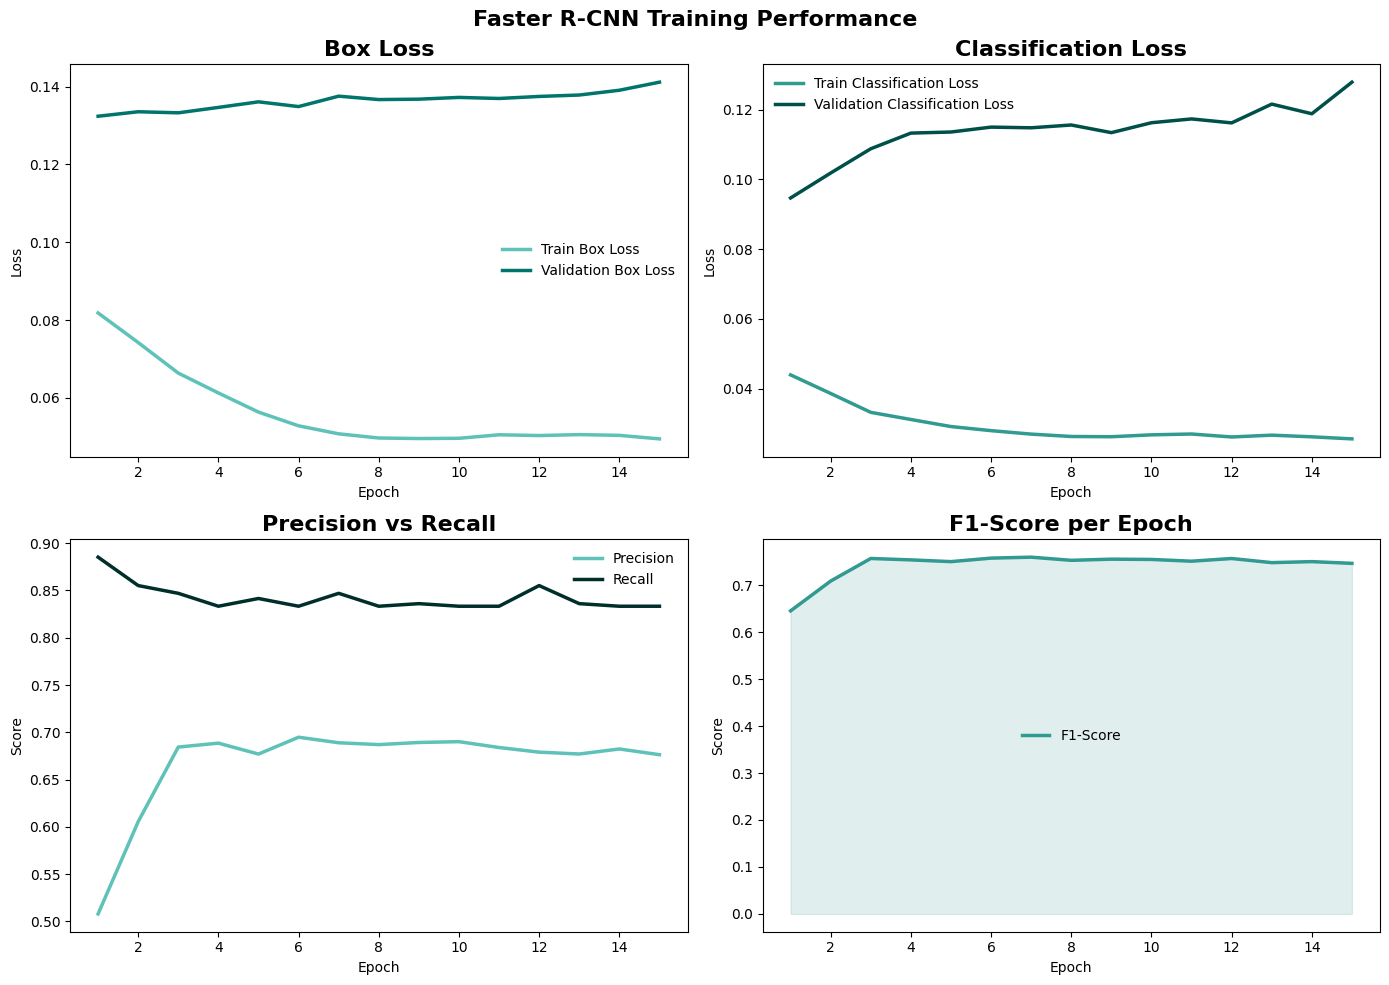

In [ ]:
# Faster R-CNN training curves

# Define epoch range
epochs_range = range(1, SHARED_EPOCHS + 1)

# Create subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Box loss curves
axes[0].plot(epochs_range, frcnn_history["train_box_loss"], label="Train Box Loss", linewidth=2.5, color=C[0])
axes[0].plot(epochs_range, frcnn_history["val_box_loss"], label="Validation Box Loss", linewidth=2.5, color=C[2])

axes[0].set_title("Box Loss", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(frameon=False)

# Classification loss curves
axes[1].plot(epochs_range, frcnn_history["train_cls_loss"], label="Train Classification Loss", linewidth=2.5, color=C[1])
axes[1].plot(epochs_range, frcnn_history["val_cls_loss"], label="Validation Classification Loss", linewidth=2.5, color=C[3])

axes[1].set_title("Classification Loss", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(frameon=False)

# Precision and recall curves
axes[2].plot(epochs_range, frcnn_history["precision"], label="Precision", linewidth=2.5, color=C[0])
axes[2].plot(epochs_range, frcnn_history["recall"], label="Recall", linewidth=2.5, color=C[4])

axes[2].set_title("Precision vs Recall", fontsize=16, fontweight='bold')
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Score")
axes[2].legend(frameon=False)

# Compute F1-score
f1_per_epoch = [
    2 * p * r / (p + r + 1e-6)
    for p, r in zip(
        frcnn_history["precision"],
        frcnn_history["recall"]
    )
]

# Plot F1-score curve
axes[3].plot(epochs_range, f1_per_epoch, label="F1-Score", linewidth=2.5, color=C[1])

axes[3].fill_between(
    epochs_range,
    f1_per_epoch,
    alpha=0.15,
    color=C[1]
)

axes[3].set_title("F1-Score per Epoch", fontsize=16, fontweight='bold')
axes[3].set_xlabel("Epoch"); axes[3].set_ylabel("Score")
axes[3].legend(frameon=False)

# Add overall title
plt.suptitle(
    "Faster R-CNN Training Performance",
    fontsize=16,
    fontweight='bold'
)

# Adjust layout
plt.tight_layout()

# Display plots
plt.show()

Faster R-CNN showed stable training with decreasing train losses and consistent precision-recall performance across epochs. The model achieved high recall above 0.83, indicating effective pothole detection. However, increasing validation loss suggests slight overfitting, while moderate precision values indicate the presence of some false positive detections.

In [ ]:
# Faster R-CNN evaluation

# Confidence threshold specific to Faster R-CNN (higher than shared default)
FRCNN_CONF_THRESH = 0.4

# Set model to evaluation mode
frcnn_model.eval()

# Initialise evaluation metrics
tp_fr = fp_fr = fn_fr = 0
iou_scores_fr = []

# Disable gradient computation
with torch.no_grad():

    # Process test batches
    for images, targets in test_loader:
        images = [img.to(device) for img in images]

        # Run inference
        outputs = frcnn_model(images)

        # Process predictions
        for output, target in zip(outputs, targets):

            # Load ground truth boxes
            gt_boxes_fr = target["boxes"].cpu().numpy().tolist()

            # Filter predicted boxes and sort by confidence descending
            scored_preds = sorted(
                [
                    (score.item(), box.cpu().numpy().tolist())
                    for box, score in zip(output["boxes"], output["scores"])
                    if score.item() >= FRCNN_CONF_THRESH
                ],
                key=lambda x: x[0],
                reverse=True,
            )
            pred_boxes = [box for _, box in scored_preds]

            matched_gt = set()

            # Match predictions with ground truth
            for pb in pred_boxes:
                best_iou, best_gi = 0, -1

                for gi, gb in enumerate(gt_boxes_fr):
                    sc = iou_single(pb, gb)
                    if sc > best_iou:
                        best_iou, best_gi = sc, gi

                # Update metrics
                if best_iou >= IOU_THRESH and best_gi not in matched_gt:
                    tp_fr += 1
                    matched_gt.add(best_gi)
                    iou_scores_fr.append(best_iou)
                else:
                    fp_fr += 1

            fn_fr += len(gt_boxes_fr) - len(matched_gt)

In [ ]:
# Compute evaluation metrics
precision_fr = tp_fr / (tp_fr + fp_fr + 1e-6)
recall_fr = tp_fr / (tp_fr + fn_fr + 1e-6)
f1_fr = (
    2 * precision_fr * recall_fr /
    (precision_fr + recall_fr + 1e-6)
)
mean_iou_fr = (
    float(np.mean(iou_scores_fr))
    if iou_scores_fr else 0.0
)

# Display test results
print("Faster R-CNN — Test Set Results:")
print(f"Precision : {precision_fr:.4f}")
print(f"Recall    : {recall_fr:.4f}")
print(f"F1-score  : {f1_fr:.4f}")
print(f"Mean IoU  : {mean_iou_fr:.4f}")
print(f"TP={tp_fr}  FP={fp_fr}  FN={fn_fr}")

Faster R-CNN — Test Set Results:
Precision : 0.7389
Recall    : 0.7205
F1-score  : 0.7296
Mean IoU  : 0.8165
TP=116  FP=41  FN=45


Faster R-CNN achieved balanced performance with precision of 0.7389, recall of 0.7205 and F1-score of 0.7296. The model correctly detected 116 potholes with mean IoU of 0.8165, showing good localisation accuracy. However, 41 false positives and 45 false negatives indicate moderate detection errors in challenging road conditions.

In [ ]:
# Draw bounding boxes on image
def draw_boxes_on_image(image_np, boxes, scores=None, color_rgb=(0, 117, 108), label="pothole"):

    # Copy image
    img = (image_np).astype(np.uint8).copy()

    # Convert RGB to BGR
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Convert color format
    color_bgr = (color_rgb[2], color_rgb[1], color_rgb[0])

    # Draw bounding boxes
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = [int(v) for v in box]
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color_bgr, 2)

        # Create label text
        text = f"{scores[i]:.2f}" if scores is not None else label

        # Get text size
        (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        text_y = max(y1 - 4, th + 4)

        # Draw label background
        cv2.rectangle(
            img_bgr,
            (x1, text_y - th - baseline),
            (x1 + tw + 4, text_y + baseline),
            color_bgr,
            -1
        )

        # Draw label text
        cv2.putText(
            img_bgr,
            text,
            (x1 + 2, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

    # Convert BGR to RGB
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

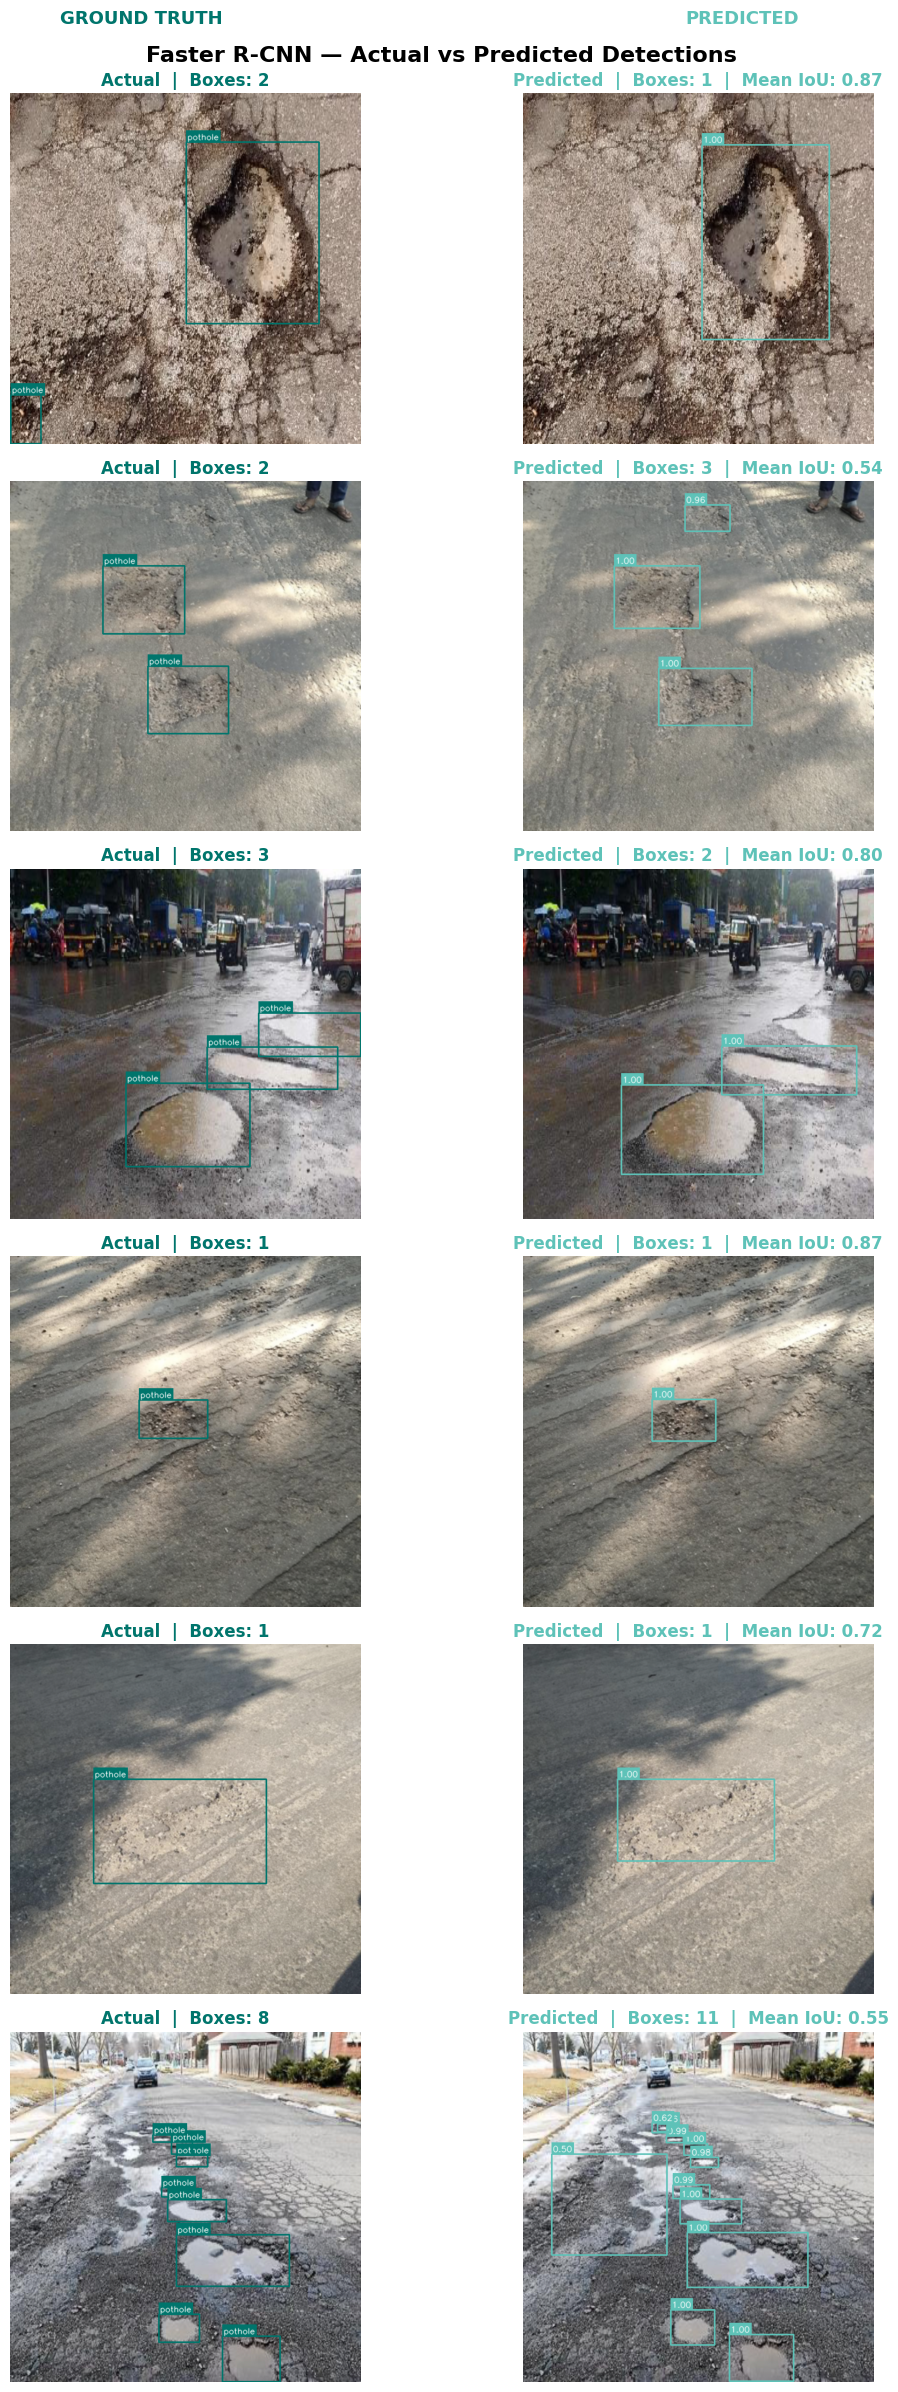

In [ ]:
# Actual vs Predicted

# Define box colors
GT_COLOR   = (0, 117, 108)
PRED_COLOR = (94, 194, 184)

# Select random test samples
NUM_SAMPLES = 6
sample_indices = random.sample(range(len(test_dataset)), NUM_SAMPLES)

# Set model to evaluation mode
frcnn_model.eval()

# Create subplot layout
fig, axes = plt.subplots(NUM_SAMPLES, 2, figsize=(12, NUM_SAMPLES * 4))

# Process sample images
for row, idx in enumerate(sample_indices):

    image_tensor, target = test_dataset[idx]

    # Run inference
    with torch.no_grad():
        output = frcnn_model([image_tensor.to(device)])[0]

    # Load raw image
    raw_image = test_dataset.get_raw_image(idx)

    # Load ground truth boxes
    gt_boxes = target["boxes"].cpu().numpy().tolist()

    # Filter predicted boxes
    pred_boxes = [
        box.cpu().numpy().tolist()
        for box, score in zip(output["boxes"], output["scores"])
        if score.item() >= CONF_THRESH
    ]

    # Filter prediction scores
    pred_scores = [
        score.item()
        for score in output["scores"]
        if score.item() >= CONF_THRESH
    ]

    # Draw ground truth and prediction boxes
    gt_img = draw_boxes_on_image(raw_image, gt_boxes, scores=None, color_rgb=GT_COLOR, label="pothole")

    pred_img = draw_boxes_on_image(raw_image, pred_boxes, scores=pred_scores, color_rgb=PRED_COLOR)

    # Display ground truth image
    axes[row, 0].imshow(gt_img)

    axes[row, 0].set_title(
        f"Actual  |  Boxes: {len(gt_boxes)}",
        fontsize=12,
        fontweight='bold',
        color=C[2]
    )

    axes[row, 0].axis("off")

    # Display prediction image
    axes[row, 1].imshow(pred_img)

    # Calculate mean IoU
    if len(gt_boxes) > 0 and len(pred_boxes) > 0:

        best_ious = [
            max((iou_single(pb, gb) for gb in gt_boxes), default=0.0)
            for pb in pred_boxes
        ]

        mean_img_iou = np.mean(best_ious)

        right_title = (
            f"Predicted  |  Boxes: {len(pred_boxes)}  |  "
            f"Mean IoU: {mean_img_iou:.2f}"
        )

    else:
        right_title = f"Predicted  |  Boxes: {len(pred_boxes)}"

    axes[row, 1].set_title(
        right_title,
        fontsize=12,
        fontweight='bold',
        color=C[0]
    )

    axes[row, 1].axis("off")

# Add column headings
fig.text(
    0.25,
    0.995,
    "GROUND TRUTH",
    ha='center',
    va='top',
    fontsize=13,
    fontweight='bold',
    color=C[2]
)

fig.text(
    0.75,
    0.995,
    "PREDICTED",
    ha='center',
    va='top',
    fontsize=13,
    fontweight='bold',
    color=C[0]
)

# Add overall title
plt.suptitle(
    "Faster R-CNN — Actual vs Predicted Detections",
    fontsize=16,
    fontweight='bold'
)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.99])

# Display plots
plt.show()

The visual results show that Faster R-CNN successfully detected potholes in different road environments with good localisation accuracy and high confidence scores. The model performed well on large and clear potholes, but some images contained extra detections and missed potholes, indicating moderate false positives and difficulty in complex road scenes.

##  **SSD MobileNet Model**

SSD MobileNet is a lightweight one-stage object detection model that combines the Single Shot Detector architecture with the MobileNet backbone network. It performs object localisation and classification in a single forward pass, making it suitable for fast and efficient real-time pothole detection applications.

SSD MobileNet was selected because of its low computational complexity and fast inference speed compared to heavier detection models. The model is suitable for resource-constrained systems and mobile-based road monitoring applications where real-time pothole detection and reduced hardware requirements are important.


In [ ]:
# SSD MobileNet Model

def get_ssd_model(num_classes):

    model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(
        weights          = None,
        weights_backbone = torchvision.models.MobileNet_V3_Large_Weights.IMAGENET1K_V1,
        num_classes      = num_classes
    )

    return model

In [ ]:
# SSD datasets using raw images from BASE

# Create SSD training dataset
ssd_train_dataset = PotholeDataset(
    image_dir      = BASE / "train" / "images",
    annotation_dir = BASE / "train" / "annotations",
    transforms     = True
)

# Create SSD validation dataset
ssd_val_dataset = PotholeDataset(
    image_dir      = BASE / "val" / "images",
    annotation_dir = BASE / "val" / "annotations",
    transforms     = False
)

# Create SSD test dataset
ssd_test_dataset = PotholeDataset(
    image_dir      = BASE / "test" / "images",
    annotation_dir = BASE / "test" / "annotations",
    transforms     = False
)

# Display dataset sizes
print(f"SSD Train Samples : {len(ssd_train_dataset)}")
print(f"SSD Val Samples   : {len(ssd_val_dataset)}")
print(f"SSD Test Samples  : {len(ssd_test_dataset)}")

SSD Train Samples : 465
SSD Val Samples   : 133
SSD Test Samples  : 67


In [ ]:
# SSD DataLoaders

# Create SSD training dataloader
ssd_train_loader = DataLoader(
    ssd_train_dataset,
    batch_size     = SHARED_BATCH,
    shuffle        = True,
    collate_fn     = lambda x: tuple(zip(*x)),
    worker_init_fn = lambda _: np.random.seed(42),
    num_workers    = 2,
    pin_memory     = torch.cuda.is_available(),
    drop_last      = True
)

# Create SSD validation dataloader
ssd_val_loader = DataLoader(
    ssd_val_dataset,
    batch_size  = SHARED_BATCH,
    shuffle     = False,
    collate_fn  = lambda x: tuple(zip(*x)),
    num_workers = 2,
    pin_memory  = torch.cuda.is_available(),
    drop_last   = True
)

# Create SSD test dataloader
ssd_test_loader = DataLoader(
    ssd_test_dataset,
    batch_size  = 1,
    shuffle     = False,
    collate_fn  = lambda x: tuple(zip(*x)),
    num_workers = 2,
    pin_memory  = torch.cuda.is_available()
)

# Display batch counts
print(f"Train batches : {len(ssd_train_loader)}")
print(f"Val batches   : {len(ssd_val_loader)}")
print(f"Test batches  : {len(ssd_test_loader)}")

Train batches : 116
Val batches   : 33
Test batches  : 67


In [ ]:
# SSD device, model, optimizer, scheduler

# Load SSD model
ssd_model = get_ssd_model(num_classes=2).to(device)

# Separate backbone parameters
backbone_params = [
    p for n, p in ssd_model.named_parameters()
    if 'backbone' in n and p.requires_grad
]

# Separate detection head parameters
head_params = [
    p for n, p in ssd_model.named_parameters()
    if 'backbone' not in n and p.requires_grad
]

# Create optimizer
ssd_optimizer = torch.optim.SGD(
    [
        {'params': backbone_params, 'lr': 0.001},
        {'params': head_params,     'lr': 0.01},
    ],
    momentum     = 0.9,
    weight_decay = 0.0005
)

# Create cosine annealing scheduler
ssd_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ssd_optimizer,
    T_max   = SHARED_EPOCHS,
    eta_min = 1e-5
)

# Display model information
print(f"Device          : {device}")
print(f"Backbone params : {len(backbone_params):,}")
print(f"Head params     : {len(head_params):,}")

print("SSD MobileNet ready.")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 145MB/s] 


Device          : cuda
Backbone params : 206
Head params     : 60
SSD MobileNet ready.


### Model Training

In [ ]:
# Store training history
ssd_history = {
    "train_loss" : [],
    "val_loss"   : [],
    "precision"  : [],
    "recall"     : [],
}

# Confidence threshold for evaluation
TRAIN_EVAL_CONF = 0.4

In [ ]:
# Training loop
for epoch in range(SHARED_EPOCHS):

    # Training phase
    ssd_model.train()

    ep_train_loss = 0.0

    # Process training batches
    for images, targets in ssd_train_loader:

        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        # Compute losses
        loss_dict = ssd_model(images, targets)

        losses = sum(loss_dict.values())

        # Backpropagation
        ssd_optimizer.zero_grad()

        losses.backward()

        # Apply gradient clipping
        torch.nn.utils.clip_grad_norm_(
            ssd_model.parameters(),
            max_norm=5.0
        )

        ssd_optimizer.step()

        ep_train_loss += losses.item()

    # Store training loss
    ssd_history["train_loss"].append(
        ep_train_loss / len(ssd_train_loader)
    )

    # Validation loss
    ssd_model.train()

    ep_val_loss = 0.0

    with torch.no_grad():

        for images, targets in ssd_val_loader:

            images = [img.to(device) for img in images]

            targets = [
                {k: v.to(device) for k, v in t.items()}
                for t in targets
            ]

            # Compute validation loss
            loss_dict = ssd_model(images, targets)

            ep_val_loss += sum(loss_dict.values()).item()

    # Store validation loss
    ssd_history["val_loss"].append(
        ep_val_loss / len(ssd_val_loader)
    )

    # Validation precision and recall
    ssd_model.eval()

    ep_tp, ep_fp, ep_fn = 0, 0, 0

    with torch.no_grad():

        for images, targets in ssd_val_loader:

            images = [img.to(device) for img in images]

            outputs = ssd_model(images)

            # Process predictions
            for output, target in zip(outputs, targets):

                pred_boxes_ep = [
                    b.cpu().numpy().tolist()
                    for b, s in zip(
                        output["boxes"],
                        output["scores"]
                    )
                    if s.item() >= TRAIN_EVAL_CONF
                ]

                gt_boxes_ep = target["boxes"].cpu().numpy().tolist()

                matched = set()

                # Match predictions with ground truth
                for pb in pred_boxes_ep:

                    best_iou, best_gi = 0, -1

                    for gi, gb in enumerate(gt_boxes_ep):

                        sc = iou_single(pb, gb)

                        if sc > best_iou:
                            best_iou, best_gi = sc, gi

                    if best_iou >= IOU_THRESH and best_gi not in matched:

                        ep_tp += 1

                        matched.add(best_gi)

                    else:
                        ep_fp += 1

                ep_fn += len(gt_boxes_ep) - len(matched)

    # Compute metrics
    ep_prec = ep_tp / (ep_tp + ep_fp + 1e-6)

    ep_rec = ep_tp / (ep_tp + ep_fn + 1e-6)

    # Store evaluation metrics
    ssd_history["precision"].append(ep_prec)

    ssd_history["recall"].append(ep_rec)

    # Update learning rate
    ssd_scheduler.step()

    # Display epoch results
    print(
        f"Epoch [{epoch+1:>2}/{SHARED_EPOCHS}]  "
        f"Train: {ssd_history['train_loss'][-1]:.4f}  "
        f"Val: {ssd_history['val_loss'][-1]:.4f}  "
        f"P: {ep_prec:.3f}  R: {ep_rec:.3f}"
    )

# Save trained model
torch.save(
    ssd_model.state_dict(),
    "/kaggle/working/ssd_pothole.pth"
)

print("SSD MobileNet training complete.")

Epoch [ 1/15]  Train: 5.9951  Val: 5.2286  P: 0.087  R: 0.310
Epoch [ 2/15]  Train: 4.8069  Val: 4.9045  P: 0.559  R: 0.208
Epoch [ 3/15]  Train: 4.4107  Val: 4.6051  P: 0.459  R: 0.258
Epoch [ 4/15]  Train: 4.1118  Val: 4.5024  P: 0.427  R: 0.282
Epoch [ 5/15]  Train: 3.9193  Val: 4.3479  P: 0.554  R: 0.282
Epoch [ 6/15]  Train: 3.7134  Val: 4.3816  P: 0.625  R: 0.301
Epoch [ 7/15]  Train: 3.5912  Val: 4.2601  P: 0.589  R: 0.318
Epoch [ 8/15]  Train: 3.4248  Val: 4.1565  P: 0.560  R: 0.334
Epoch [ 9/15]  Train: 3.2958  Val: 4.1551  P: 0.634  R: 0.337
Epoch [10/15]  Train: 3.1940  Val: 4.0798  P: 0.632  R: 0.348
Epoch [11/15]  Train: 3.1158  Val: 4.0806  P: 0.625  R: 0.342
Epoch [12/15]  Train: 3.0730  Val: 4.0513  P: 0.564  R: 0.386
Epoch [13/15]  Train: 3.0423  Val: 4.0400  P: 0.636  R: 0.359
Epoch [14/15]  Train: 3.0300  Val: 4.0263  P: 0.598  R: 0.367
Epoch [15/15]  Train: 3.0082  Val: 4.0259  P: 0.609  R: 0.367
SSD MobileNet training complete.


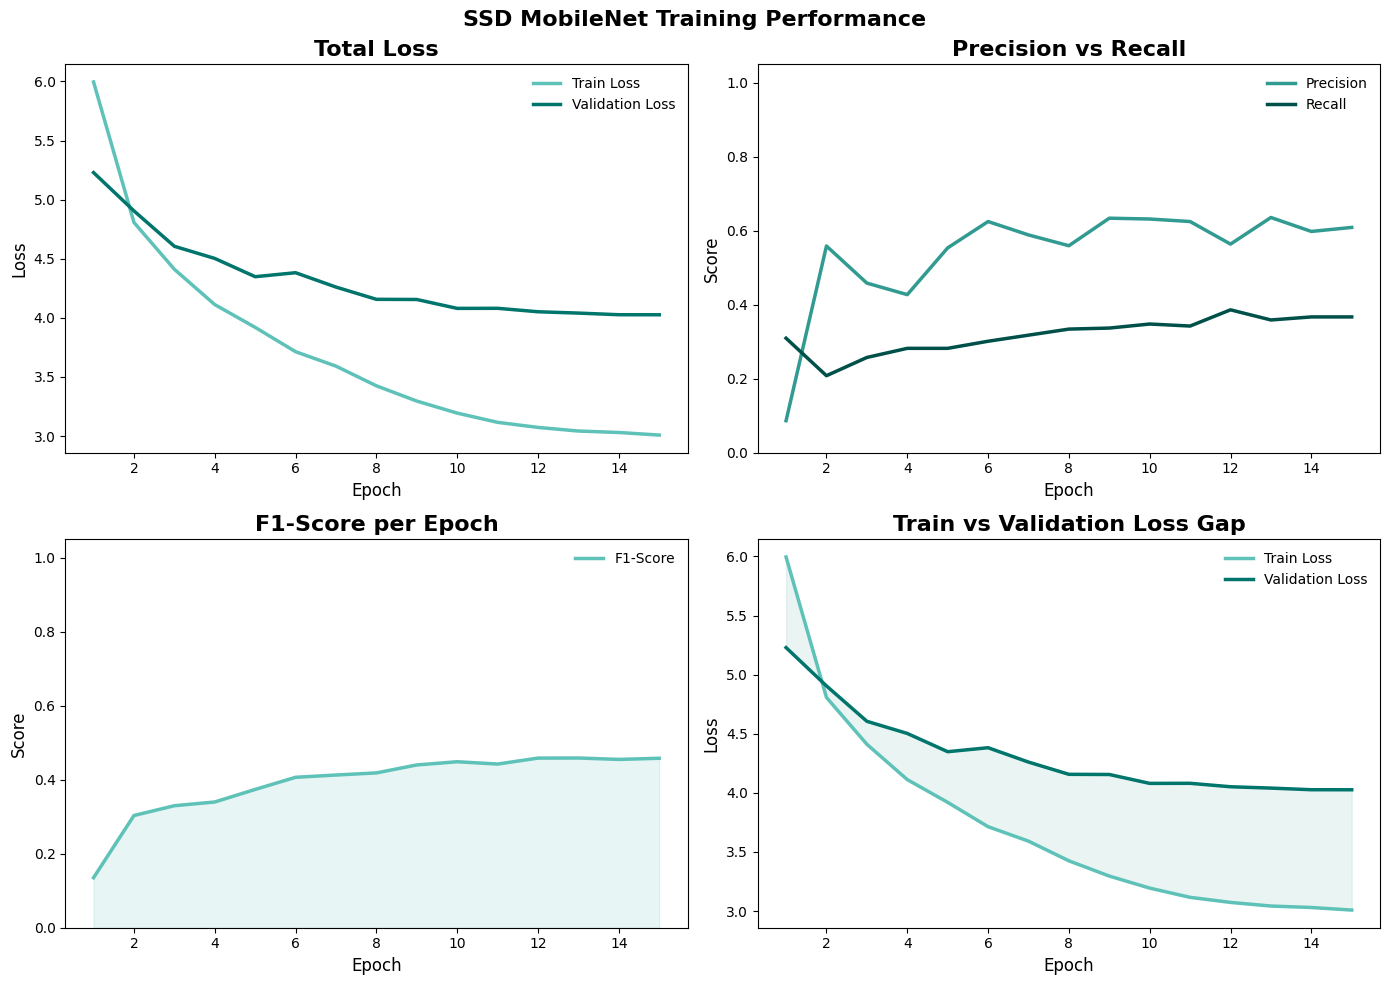

In [ ]:
# SSD MobileNet Training and Validation Curves

# Create epoch range
epochs_range = range(1, SHARED_EPOCHS + 1)

# Create subplot figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten axes array
axes = axes.flatten()

# Total Loss Curve

# Plot training loss
axes[0].plot(
    epochs_range,
    ssd_history["train_loss"],
    label="Train Loss",
    linewidth=2.5,
    color=C[0]
)

# Plot validation loss
axes[0].plot(
    epochs_range,
    ssd_history["val_loss"],
    label="Validation Loss",
    linewidth=2.5,
    color=C[2]
)

# Add title and labels
axes[0].set_title("Total Loss", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)

# Show legend
axes[0].legend(frameon=False)

# Precision vs Recall Curve

# Plot precision
axes[1].plot(
    epochs_range,
    ssd_history["precision"],
    label="Precision",
    linewidth=2.5,
    color=C[1]
)

# Plot recall
axes[1].plot(
    epochs_range,
    ssd_history["recall"],
    label="Recall",
    linewidth=2.5,
    color=C[3]
)

# Add title and labels
axes[1].set_title(
    "Precision vs Recall",
    fontsize=16,
    fontweight='bold'
)

axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_ylim(0, 1.05)

# Show legend
axes[1].legend(frameon=False)

# F1-Score Curve

# Calculate F1-score
f1_ssd_curve = [
    2 * p * r / (p + r + 1e-6)
    for p, r in zip(
        ssd_history["precision"],
        ssd_history["recall"]
    )
]

# Plot F1-score
axes[2].plot(
    epochs_range,
    f1_ssd_curve,
    label="F1-Score",
    linewidth=2.5,
    color=C[0]
)

# Fill area under curve
axes[2].fill_between(
    epochs_range,
    f1_ssd_curve,
    alpha=0.15,
    color=C[0]
)

# Add title and labels
axes[2].set_title(
    "F1-Score per Epoch",
    fontsize=16,
    fontweight='bold'
)

axes[2].set_xlabel("Epoch", fontsize=12)
axes[2].set_ylabel("Score", fontsize=12)
axes[2].set_ylim(0, 1.05)

# Show legend
axes[2].legend(frameon=False)

# Train vs Validation Loss Gap

# Plot train loss
axes[3].plot(
    epochs_range,
    ssd_history["train_loss"],
    label="Train Loss",
    linewidth=2.5,
    color=C[0]
)

# Plot validation loss
axes[3].plot(
    epochs_range,
    ssd_history["val_loss"],
    label="Validation Loss",
    linewidth=2.5,
    color=C[2]
)

# Fill loss gap area
axes[3].fill_between(
    epochs_range,
    ssd_history["train_loss"],
    ssd_history["val_loss"],
    alpha=0.10,
    color=C[1]
)

# Add title and labels
axes[3].set_title(
    "Train vs Validation Loss Gap",
    fontsize=16,
    fontweight='bold'
)

axes[3].set_xlabel("Epoch", fontsize=12)
axes[3].set_ylabel("Loss", fontsize=12)

# Show legend
axes[3].legend(frameon=False)

# Add main title
plt.suptitle(
    "SSD MobileNet Training Performance",
    fontsize=16,
    fontweight='bold'
)

# Adjust layout
plt.tight_layout()

# Display plots
plt.show()

SSD MobileNet showed gradual improvement across 15 epochs, with train loss decreasing from 5.99 to 3.00. The model achieved precision of 0.609 and recall of 0.367, indicating moderate detection capability. Lower F1-score and validation performance suggest weaker generalisation and reduced accuracy.

In [ ]:
# SSD evaluation on test set

# Set confidence threshold
SSD_CONF_THRESH = CONF_THRESH

# Set model to evaluation mode
ssd_model.eval()

# Initialize evaluation metrics
tp_ssd = fp_ssd = fn_ssd = 0

iou_scores_ssd = []

# Disable gradient computation
with torch.no_grad():

    # Process test batches
    for images, targets in ssd_test_loader:

        images = [img.to(device) for img in images]

        # Run inference
        outputs = ssd_model(images)

        # Process predictions
        for output, target in zip(outputs, targets):

            # Load ground truth boxes
            gt_boxes_ssd = target["boxes"].cpu().numpy().tolist()

            # Filter predicted boxes
            pred_boxes_ssd = [
                box.cpu().numpy().tolist()
                for box, score in zip(
                    output["boxes"],
                    output["scores"]
                )
                if score.item() >= SSD_CONF_THRESH
            ]

            matched_gt = set()

            # Match predictions with ground truth
            for pb in pred_boxes_ssd:

                best_iou, best_gi = 0, -1

                for gi, gb in enumerate(gt_boxes_ssd):

                    sc = iou_single(pb, gb)

                    if sc > best_iou:
                        best_iou, best_gi = sc, gi

                # Update metrics
                if best_iou >= IOU_THRESH and best_gi not in matched_gt:

                    tp_ssd += 1

                    matched_gt.add(best_gi)

                    iou_scores_ssd.append(best_iou)

                else:
                    fp_ssd += 1

            fn_ssd += len(gt_boxes_ssd) - len(matched_gt)

In [ ]:
# Compute evaluation metrics
precision_ssd = tp_ssd / (tp_ssd + fp_ssd + 1e-6)

recall_ssd = tp_ssd / (tp_ssd + fn_ssd + 1e-6)

f1_ssd_final = (
    2 * precision_ssd * recall_ssd /
    (precision_ssd + recall_ssd + 1e-6)
)

mean_iou_ssd = (
    float(np.mean(iou_scores_ssd))
    if iou_scores_ssd else 0.0
)

# Display test results
print("SSD MobileNet — Test Set Results:")

print(f"Precision : {precision_ssd:.4f}")
print(f"Recall    : {recall_ssd:.4f}")
print(f"F1-score  : {f1_ssd_final:.4f}")
print(f"Mean IoU  : {mean_iou_ssd:.4f}")

print(f"TP={tp_ssd}  FP={fp_ssd}  FN={fn_ssd}")

SSD MobileNet — Test Set Results:
Precision : 0.6055
Recall    : 0.4099
F1-score  : 0.4889
Mean IoU  : 0.6755
TP=66  FP=43  FN=95


SSD MobileNet achieved precision of 0.6055 and recall of 0.4099 with F1-score of 0.4889. The model correctly detected 66 potholes, but 43 false positives and 95 false negatives indicate weaker detection performance and lower localisation accuracy compared to other models.

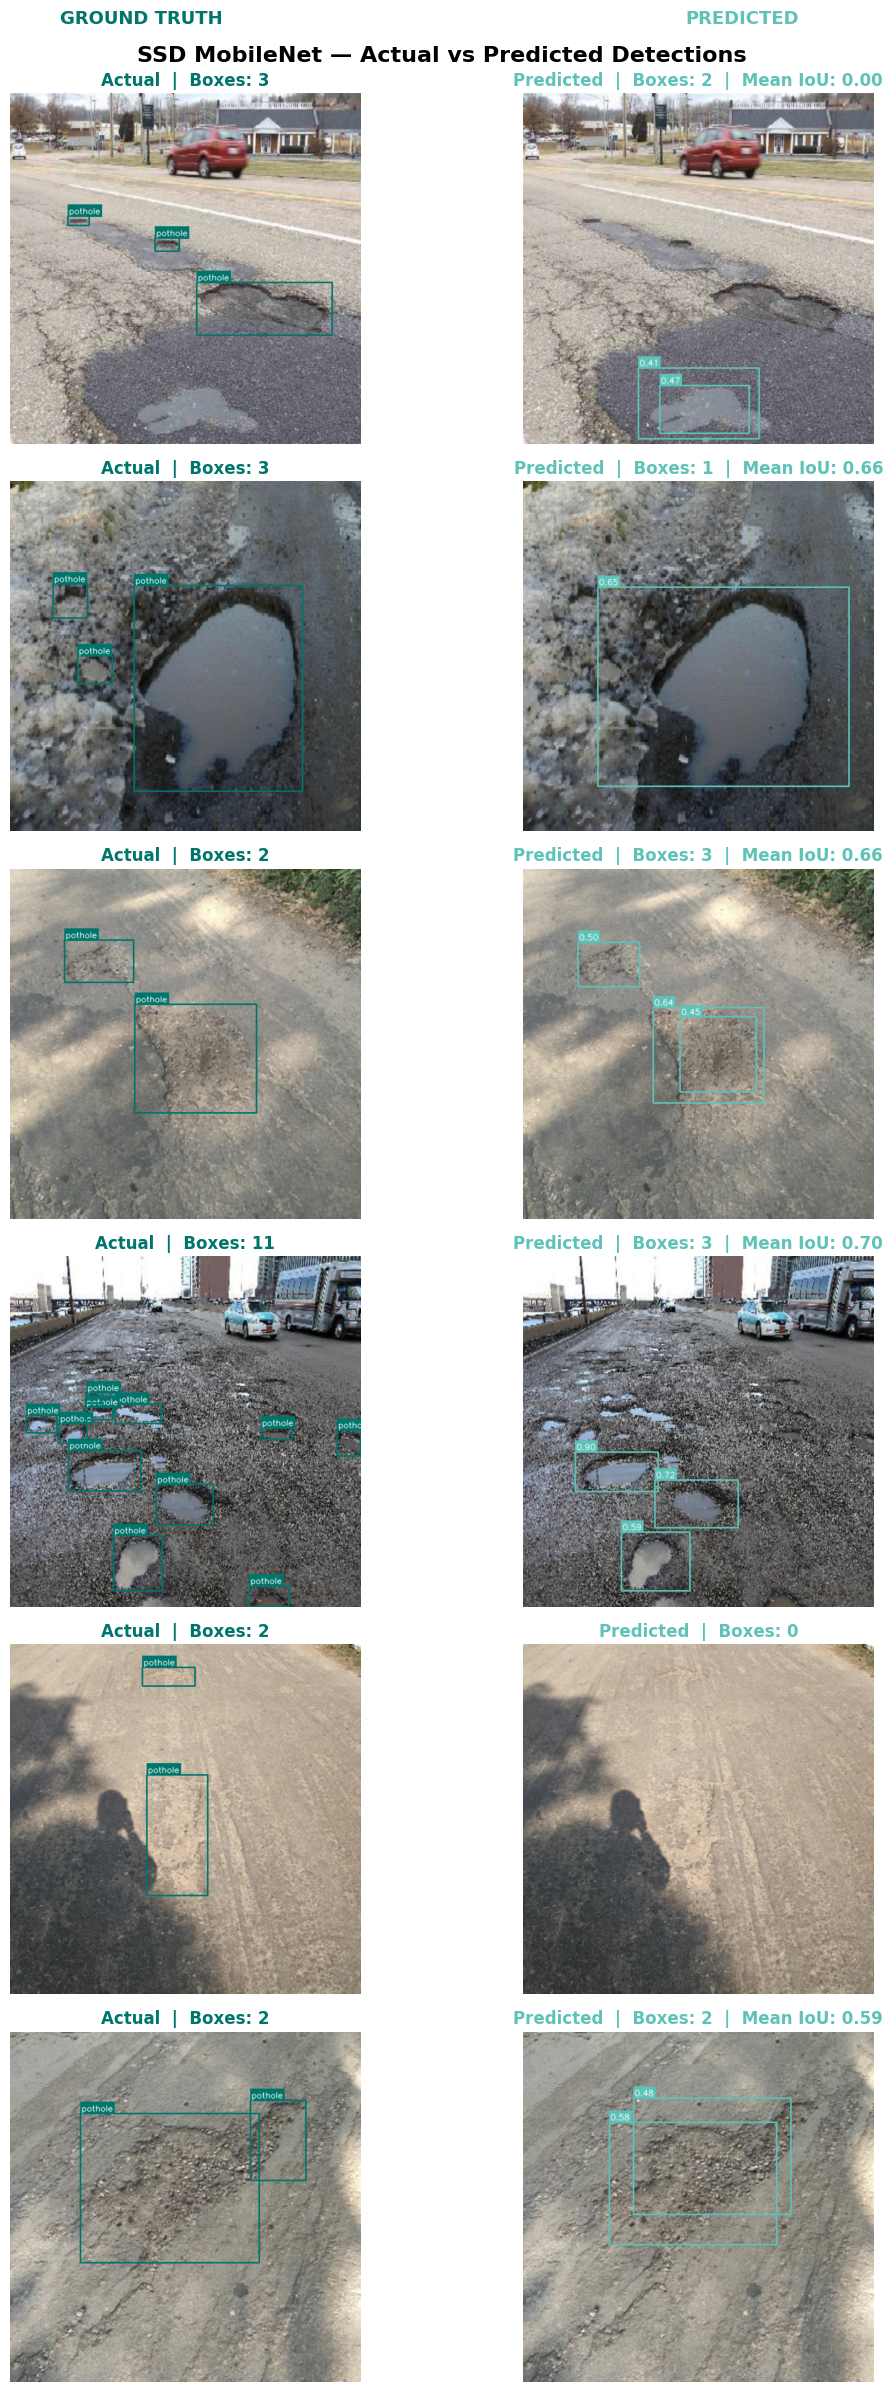

In [ ]:
# SSD MobileNet — Actual vs Predicted

# Define box colors
GT_COLOR   = (0,  117, 108)
PRED_COLOR = (94, 194, 184)

# Select random test samples
NUM_SAMPLES = 6
ssd_indices = random.sample(range(len(ssd_test_dataset)), NUM_SAMPLES)

# Set model to evaluation mode
ssd_model.eval()

# Create subplot layout
fig, axes = plt.subplots(NUM_SAMPLES, 2, figsize=(12, NUM_SAMPLES * 4))

# Process sample images
for row, idx in enumerate(ssd_indices):

    image_tensor, target = ssd_test_dataset[idx]

    # Run inference
    with torch.no_grad():
        output = ssd_model([image_tensor.to(device)])[0]

    # Load raw image
    raw_image = ssd_test_dataset.get_raw_image(idx)

    # Load ground truth boxes
    gt_boxes = target["boxes"].cpu().numpy().tolist()

    # Filter predicted boxes
    pred_boxes_s = [
        box.cpu().numpy().tolist()
        for box, score in zip(output["boxes"], output["scores"])
        if score.item() >= CONF_THRESH
    ]

    # Filter prediction scores
    pred_scores_s = [
        score.item()
        for score in output["scores"]
        if score.item() >= CONF_THRESH
    ]

    # Draw ground truth and predicted boxes
    gt_img = draw_boxes_on_image(raw_image, gt_boxes,
                                   scores=None, color_rgb=GT_COLOR, label="pothole")

    pred_img = draw_boxes_on_image(raw_image, pred_boxes_s,
                                   scores=pred_scores_s, color_rgb=PRED_COLOR)

    # Display ground truth image
    axes[row, 0].imshow(gt_img)

    axes[row, 0].set_title(f"Actual  |  Boxes: {len(gt_boxes)}",
                            fontsize=12, fontweight='bold', color=C[2])

    axes[row, 0].axis("off")

    # Calculate mean IoU
    if gt_boxes and pred_boxes_s:

        best_ious = [max((iou_single(pb, gb) for gb in gt_boxes), default=0.0)
                       for pb in pred_boxes_s]

        right_title = (f"Predicted  |  Boxes: {len(pred_boxes_s)}  |  "
                       f"Mean IoU: {np.mean(best_ious):.2f}")

    else:
        right_title = f"Predicted  |  Boxes: {len(pred_boxes_s)}"

    # Display prediction image
    axes[row, 1].imshow(pred_img)

    axes[row, 1].set_title(right_title, fontsize=12, fontweight='bold', color=C[0])

    axes[row, 1].axis("off")

# Add column headings
fig.text(0.25, 0.995, "GROUND TRUTH", ha='center', va='top',
         fontsize=13, fontweight='bold', color=C[2])

fig.text(0.75, 0.995, "PREDICTED", ha='center', va='top',
         fontsize=13, fontweight='bold', color=C[0])

# Add overall title
plt.suptitle("SSD MobileNet — Actual vs Predicted Detections",
             fontsize=16, fontweight='bold')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.99])

# Display plots
plt.show()

SSD MobileNet detected potholes in simple road scenes with moderate confidence and acceptable IoU scores. However, the model missed several potholes and produced inaccurate detections in complex images, indicating lower localisation accuracy and weaker performance on dense or challenging road conditions.

## **Model Performance Comparison**

In [ ]:
# Model Results

# YOLOv8
precision    = 0.8750
recall       = 0.5652
f1           = 0.6868
mean_iou     = 0.8342
tp           = 91
fp           = 13
fn           = 70

# Faster R-CNN
precision_fr = 0.7389
recall_fr    = 0.7205
f1_fr        = 0.7296
mean_iou_fr  = 0.8165
tp_fr        = 116
fp_fr        = 41
fn_fr        = 45

# SSD MobileNet
precision_ssd = 0.6055
recall_ssd    = 0.4099
f1_ssd_final  = 0.4889
mean_iou_ssd  = 0.6755
tp_ssd        = 66
fp_ssd        = 43
fn_ssd        = 95

models = ["YOLOv8", "Faster R-CNN", "SSD MobileNet"]

colors = [C[0], C[2], C[4]]

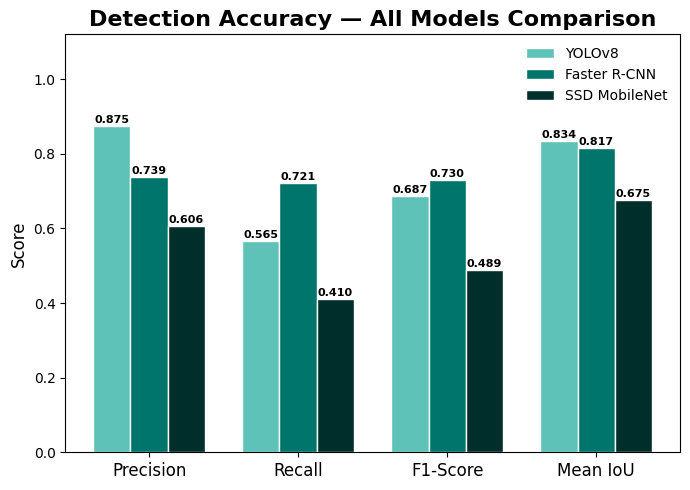

In [ ]:
# Comparative analysis — detection accuracy

# Define evaluation metrics
metrics_labels = ["Precision", "Recall", "F1-Score", "Mean IoU"]

# Store model results
yolo_vals  = [precision,      recall,      f1,           mean_iou]
frcnn_vals = [precision_fr,   recall_fr,   f1_fr,        mean_iou_fr]
ssd_vals   = [precision_ssd,  recall_ssd,  f1_ssd_final, mean_iou_ssd]

# Define bar positions
x = np.arange(len(metrics_labels))

width = 0.25

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Plot YOLOv8 bars
bars1 = ax.bar(x - width, yolo_vals, width,
               label="YOLOv8", color=C[0], edgecolor='white')

# Plot Faster R-CNN bars
bars2 = ax.bar(x, frcnn_vals, width,
               label="Faster R-CNN", color=C[2], edgecolor='white')

# Plot SSD MobileNet bars
bars3 = ax.bar(x + width, ssd_vals, width,
               label="SSD MobileNet", color=C[4], edgecolor='white')

# Add value labels on bars
for bar in list(bars1) + list(bars2) + list(bars3):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{bar.get_height():.3f}",
        ha='center',
        fontsize=8,
        fontweight='bold'
    )

# Configure axis labels
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)

# Add chart title
ax.set_title(
    "Detection Accuracy — All Models Comparison",
    fontweight='bold',
    fontsize=16
)

# Display legend
ax.legend(frameon=False)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

YOLOv8 achieved the highest precision of 0.875 and Mean IoU of 0.834, showing superior localisation accuracy. Faster R-CNN obtained the best recall of 0.721 and highest F1-score of 0.730, while SSD MobileNet showed the lowest overall performance across all evaluation metrics.

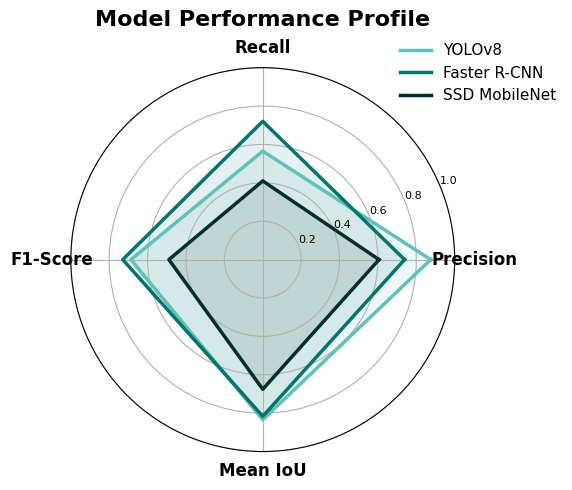

In [ ]:
# Radar chart — model performance profile

# Import required modules
import matplotlib.patches as mpatches

from matplotlib.patches import FancyArrowPatch

# Define evaluation metrics
categories = ["Precision", "Recall", "F1-Score", "Mean IoU"]

N = len(categories)

# Create radar chart angles
angles = [n / float(N) * 2 * np.pi for n in range(N)]

angles += angles[:1]

# Store model performance values
yolo_r = [precision, recall, f1, mean_iou]

frcnn_r = [precision_fr, recall_fr, f1_fr, mean_iou_fr]

ssd_r = [precision_ssd, recall_ssd, f1_ssd_final, mean_iou_ssd]

# Close radar polygons
yolo_r += yolo_r[:1]

frcnn_r += frcnn_r[:1]

ssd_r += ssd_r[:1]

# Create radar chart
fig, ax = plt.subplots(figsize=(7, 5),
                        subplot_kw=dict(polar=True))

# Plot YOLOv8 results
ax.plot(angles, yolo_r, linewidth=2.5, color=C[0], label="YOLOv8")

ax.fill(angles, yolo_r, alpha=0.10, color=C[0])

# Plot Faster R-CNN results
ax.plot(angles, frcnn_r, linewidth=2.5, color=C[2], label="Faster R-CNN")

ax.fill(angles, frcnn_r, alpha=0.10, color=C[2])

# Plot SSD MobileNet results
ax.plot(angles, ssd_r, linewidth=2.5, color=C[4], label="SSD MobileNet")

ax.fill(angles, ssd_r, alpha=0.10, color=C[4])

# Configure axis labels
ax.set_xticks(angles[:-1])

ax.set_xticklabels(categories, fontsize=12, fontweight='bold')

ax.set_ylim(0, 1)

ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])

ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)

# Display legend
ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.3, 1.1),
    frameon=False,
    fontsize=11
)

# Add chart title
plt.title(
    "Model Performance Profile",
    fontsize=16,
    fontweight='bold',
    pad=30
)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

The radar chart shows that YOLOv8 achieved the highest precision and Mean IoU, indicating strong localisation accuracy. Faster R-CNN provided the best balance with higher recall and F1-score, while SSD MobileNet showed comparatively lower performance across all evaluation metrics.

YOLOv8        : 20.5 ms/image
Faster R-CNN  : 83.7 ms/image
SSD MobileNet : 13.0 ms/image


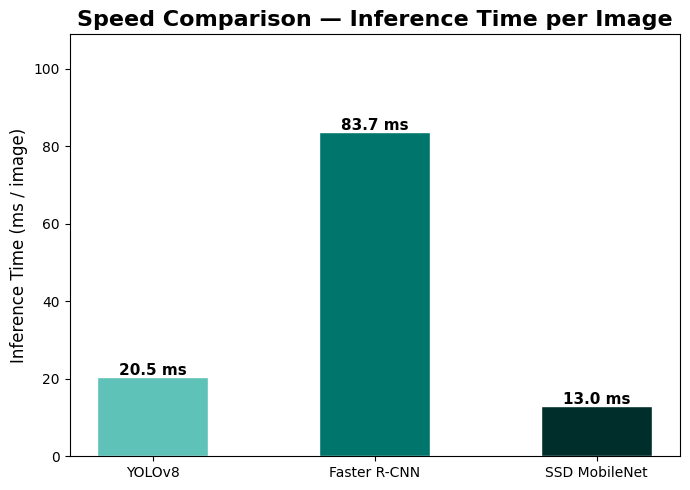

In [ ]:
# Speed comparison — inference time per image

# Import time module
import time

# Select number of images for speed testing
NUM_SPEED_IMGS = 50

# Prepare test images for PyTorch models
speed_imgs = [
    ssd_test_dataset[i][0].unsqueeze(0).to(device)
    for i in range(NUM_SPEED_IMGS)
]

# YOLOv8 inference speed
test_img_list_speed = list(
    (YOLO_DIR / "test" / "images").glob("*.jpg")
)[:NUM_SPEED_IMGS]

start = time.time()

_ = yolo_eval.predict(
    source  = [str(p) for p in test_img_list_speed],
    conf    = CONF_THRESH,
    verbose = False
)

yolo_time = (time.time() - start) / NUM_SPEED_IMGS * 1000

# Faster R-CNN inference speed
frcnn_model.eval()

start = time.time()

with torch.no_grad():

    for img in speed_imgs:

        _ = frcnn_model([img.squeeze(0)])

frcnn_time = (time.time() - start) / NUM_SPEED_IMGS * 1000

# SSD MobileNet inference speed
ssd_model.eval()

start = time.time()

with torch.no_grad():

    for img in speed_imgs:

        _ = ssd_model([img.squeeze(0)])

ssd_time = (time.time() - start) / NUM_SPEED_IMGS * 1000

# Print average inference times
print(f"YOLOv8        : {yolo_time:.1f} ms/image")

print(f"Faster R-CNN  : {frcnn_time:.1f} ms/image")

print(f"SSD MobileNet : {ssd_time:.1f} ms/image")

# Create speed comparison chart
fig, ax = plt.subplots(figsize=(7, 5))

times = [yolo_time, frcnn_time, ssd_time]

bars = ax.bar(
    models,
    times,
    color     = colors,
    edgecolor = 'white',
    width     = 0.5
)

# Add values above bars
for bar, val in zip(bars, times):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f} ms",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Configure chart labels
ax.set_ylabel("Inference Time (ms / image)", fontsize=12)

ax.set_title(
    "Speed Comparison — Inference Time per Image",
    fontweight='bold',
    fontsize=16
)

ax.set_ylim(0, max(times) * 1.3)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

SSD MobileNet achieved the fastest inference speed at 13.0 ms per image, making it suitable for lightweight real-time applications. YOLOv8 required 20.5 ms while providing higher accuracy. Faster R-CNN was the slowest at 83.7 ms, indicating higher computational complexity and reduced real-time efficiency.

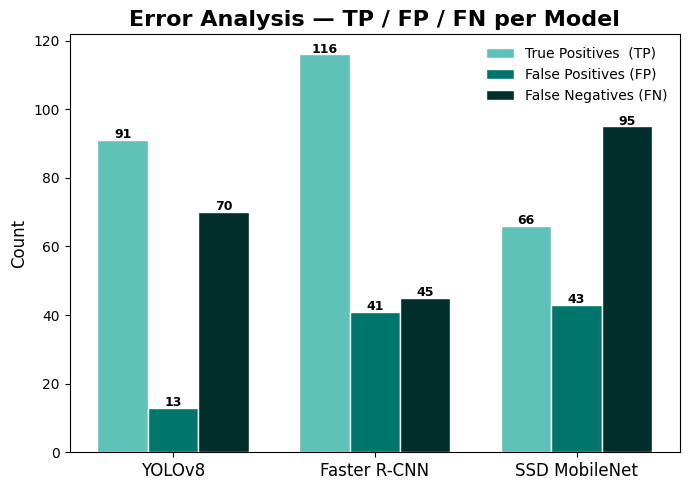

In [ ]:
# Error analysis — TP, FP, FN per model

# Store detection counts for each model
tp_vals = [tp, tp_fr, tp_ssd]

fp_vals = [fp, fp_fr, fp_ssd]

fn_vals = [fn, fn_fr, fn_ssd]

# Define bar positions
x = np.arange(len(models))

width = 0.25

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Plot true positives
b1 = ax.bar(
    x - width,
    tp_vals,
    width,
    label="True Positives  (TP)",
    color=C[0],
    edgecolor='white'
)

# Plot false positives
b2 = ax.bar(
    x,
    fp_vals,
    width,
    label="False Positives (FP)",
    color=C[2],
    edgecolor='white'
)

# Plot false negatives
b3 = ax.bar(
    x + width,
    fn_vals,
    width,
    label="False Negatives (FN)",
    color=C[4],
    edgecolor='white'
)

# Add value labels above bars
for bar in list(b1) + list(b2) + list(b3):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# Configure axis labels
ax.set_xticks(x)

ax.set_xticklabels(models, fontsize=12)

ax.set_ylabel("Count", fontsize=12)

# Add chart title
ax.set_title(
    "Error Analysis — TP / FP / FN per Model",
    fontweight='bold',
    fontsize=16
)

# Display legend
ax.legend(frameon=False)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

YOLOv8 produced the fewest false positives at 13, showing strong detection precision. Faster R-CNN achieved the highest true positives with 116 and lower false negatives. SSD MobileNet recorded the highest false negatives at 95, indicating weaker pothole detection capability and reduced reliability in challenging conditions.

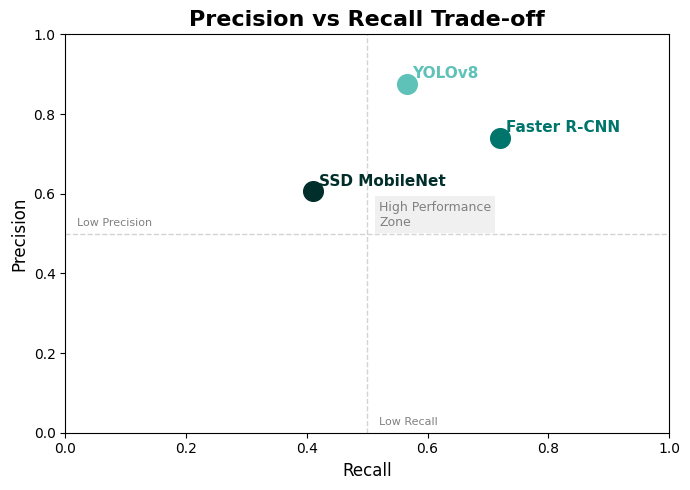

In [ ]:
# Precision vs recall trade-off analysis

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Plot precision and recall points
for (p, r, name, color) in [
    (precision,      recall,      "YOLOv8",        C[0]),
    (precision_fr,   recall_fr,   "Faster R-CNN",  C[2]),
    (precision_ssd,  recall_ssd,  "SSD MobileNet", C[4]),
]:

    ax.scatter(r, p, color=color, s=200, zorder=5)

    # Add model labels
    ax.annotate(
        name,
        xy         = (r, p),
        xytext     = (r + 0.01, p + 0.015),
        fontsize   = 11,
        fontweight = 'bold',
        color      = color
    )

# Configure axis labels
ax.set_xlabel("Recall", fontsize=12)

ax.set_ylabel("Precision", fontsize=12)

ax.set_xlim(0, 1)

ax.set_ylim(0, 1)

# Add chart title
ax.set_title(
    "Precision vs Recall Trade-off",
    fontweight='bold',
    fontsize=16
)

# Add reference lines
ax.axhline(0.5, color='lightgray', linestyle='--', linewidth=1)

ax.axvline(0.5, color='lightgray', linestyle='--', linewidth=1)

# Add performance region labels
ax.text(0.02, 0.52, "Low Precision", fontsize=8, color='gray')

ax.text(0.52, 0.02, "Low Recall", fontsize=8, color='gray')

ax.text(
    0.52,
    0.52,
    "High Performance\nZone",
    fontsize=9,
    color='gray',
    bbox=dict(facecolor='#f0f0f0', edgecolor='none', pad=3)
)

# Adjust layout
plt.tight_layout()

# Display chart
plt.show()

The precision-recall trade-off analysis shows that YOLOv8 achieved the highest precision with moderate recall, indicating accurate detections with fewer false positives. Faster R-CNN provided the best balance between precision and recall, while SSD MobileNet showed lower recall and overall weaker detection performance.

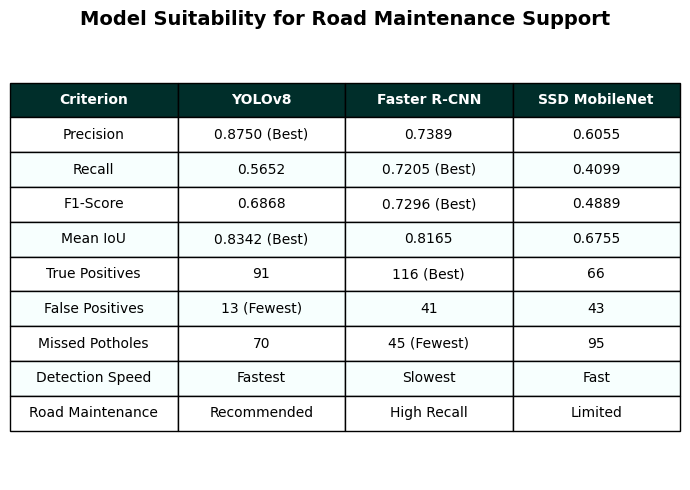

In [ ]:
# Suitability Summary Table

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Hide axes
ax.axis("off")

# Table content
table_data = [

    ["Criterion",
     "YOLOv8",
     "Faster R-CNN",
     "SSD MobileNet"],

    ["Precision",
     "0.8750 (Best)",
     "0.7389",
     "0.6055"],

    ["Recall",
     "0.5652",
     "0.7205 (Best)",
     "0.4099"],

    ["F1-Score",
     "0.6868",
     "0.7296 (Best)",
     "0.4889"],

    ["Mean IoU",
     "0.8342 (Best)",
     "0.8165",
     "0.6755"],

    ["True Positives",
     "91",
     "116 (Best)",
     "66"],

    ["False Positives",
     "13 (Fewest)",
     "41",
     "43"],

    ["Missed Potholes",
     "70",
     "45 (Fewest)",
     "95"],

    ["Detection Speed",
     "Fastest",
     "Slowest",
     "Fast"],

    ["Road Maintenance",
     "Recommended",
     "High Recall",
     "Limited"]
]

# Row colors
row_colors = []

for i, row in enumerate(table_data):

    if i == 0:

        row_colors.append([C[4]] * 4)

    elif i % 2 == 0:

        row_colors.append(["#f7fffe"] * 4)

    else:

        row_colors.append(["#ffffff"] * 4)

# Create table
table = ax.table(
    cellText=table_data,
    cellLoc='center',
    loc='center',
    cellColours=row_colors
)

# Font settings
table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(1, 1.8)

# Header style
for j in range(4):

    table[0, j].set_text_props(
        fontweight='bold',
        color='white'
    )

# Add title
plt.title(
    "Model Suitability for Road Maintenance Support",
    fontsize=14,
    fontweight='bold'
)

# Adjust layout
plt.tight_layout()

# Display table
plt.show()

The comparison shows that YOLOv8 achieved the best overall balance of precision, localisation accuracy and detection speed, making it the most suitable model for road maintenance support. Faster R-CNN provided higher recall and true positives, while SSD MobileNet delivered faster processing but lower overall detection performance.


# **Challenges and Conclusion**




## **Challenges Faced**

**Variable Pothole Size & Scale**: The dataset contained potholes of different sizes, depths and road textures, making it difficult for models to maintain consistent detection accuracy across all road conditions.

**Small Object Detection**: Many potholes occupied small image regions, creating challenges in accurate localisation and increasing the chances of missed detections, especially for SSD MobileNet.

**Annotation Quality & XML Parsing**: Processing Pascal VOC XML annotations required accurate extraction and mapping of bounding box coordinates, while handling image-annotation mismatches during dataset preparation.

**Speed vs. Accuracy Trade-Off**:YOLOv8 achieved strong precision and fast inference, Faster R-CNN achieved higher recall but slower speed, while SSD MobileNet provided fast detection with lower overall accuracy, making model selection challenging.

**False Negative Risk**: Missed potholes are critical in road safety applications. SSD MobileNet produced 95 false negatives and YOLOv8 produced 70, highlighting the challenge of improving recall without increasing false positives.


## **Conclusion**

This project successfully developed a smart pothole detection framework using YOLOv8, Faster R-CNN and SSD MobileNet. SSD MobileNet provided the fastest inference speed of 13.0 ms per image but achieved lower detection performance. Faster R-CNN achieved the highest recall of 0.7205 with 116 true positive detections and fewer missed potholes. **YOLOv8 achieved the best overall performance with precision of 0.8750, F1-score of 0.6868, Mean IoU of 0.8342** and only 13 false positives while maintaining fast inference speed of 20.5 ms per image. The results indicate that YOLOv8 is the most suitable model for automated pothole detection and road maintenance support systems.